In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Define base path
BASE_PATH = "../data/processed"

# Load all processed files
deaths_df = pd.read_csv(os.path.join(BASE_PATH, "total_accidental_deaths_2015_2022.csv"))
transport_df = pd.read_csv(os.path.join(BASE_PATH, "mode_of_transport_2015_2022.csv"))
month_df = pd.read_csv(os.path.join(BASE_PATH, "month_of_occurrence_2015_2022.csv"))
time_df = pd.read_csv(os.path.join(BASE_PATH, "time_of_occurrence_2015_2022.csv"))
road_df = pd.read_csv(os.path.join(BASE_PATH, "road_classification_2015_2022.csv"))
place_df = pd.read_csv(os.path.join(BASE_PATH, "place_of_occurrence_2015_2022.csv"))

print("All files loaded successfully!")
print(f"Deaths: {deaths_df.shape}")
print(f"Transport: {transport_df.shape}")
print(f"Month: {month_df.shape}")
print(f"Time: {time_df.shape}")
print(f"Road: {road_df.shape}")
print(f"Place: {place_df.shape}")

All files loaded successfully!
Deaths: (280, 4)
Transport: (280, 10)
Month: (280, 15)
Time: (280, 11)
Road: (280, 8)
Place: (280, 19)


In [2]:
# Create Master DataFrame - merge all files
master_df = deaths_df.merge(transport_df, on=["S.No.", "State/UT", "Year"], how="left")
master_df = master_df.merge(month_df, on=["S.No.", "State/UT", "Year"], how="left")
master_df = master_df.merge(time_df, on=["S.No.", "State/UT", "Year"], how="left")
master_df = master_df.merge(road_df, on=["S.No.", "State/UT", "Year"], how="left")
master_df = master_df.merge(place_df, on=["S.No.", "State/UT", "Year"], how="left")

print(f"Master DataFrame Shape: {master_df.shape}")
print(f"Columns: {list(master_df.columns)}")
print(f"\nMissing Values: {master_df.isnull().sum().sum()}")
print(f"\nFirst 3 rows:")
print(master_df.head(3))

Master DataFrame Shape: (280, 52)
Columns: ['S.No.', 'State/UT', 'Year', 'Total Accidental Deaths', 'Truck/Lorry/Mini Truck - Died', 'Bus - Died', 'SUV/Car/Jeep - Died', 'Tractor - Died', 'Three Wheeler/Auto Rickshaw - Died', 'Two Wheeler - Died', 'Other Motor Vehicles - Died', 'January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December', '0000 hrs to 0300 hrs (Night)', '0300 hrs to 0600 hrs (Night)', '0600 hrs to 0900 hrs (Day)', '0900 hrs to 1200 hrs (Day)', '1200 hrs to 1500 hrs (Day)', '1500 hrs to 1800 hrs (Day)', '1800 hrs to 2100 hrs (Night)', '2100 hrs to 2400 hrs (Night)', 'National Highways - Died', 'State Highways - Died', 'Expressways - Died', 'Other Roads - Died', 'Total - Died', 'Rural Area - School/College - Total', 'Rural Area - Residential - Total', 'Rural Area - Religious - Total', 'Rural Area - Recreation - Total', 'Rural Area - Factory - Total', 'Rural Area - Others - Total', 'Rural Area - Sub Total', 'Urba

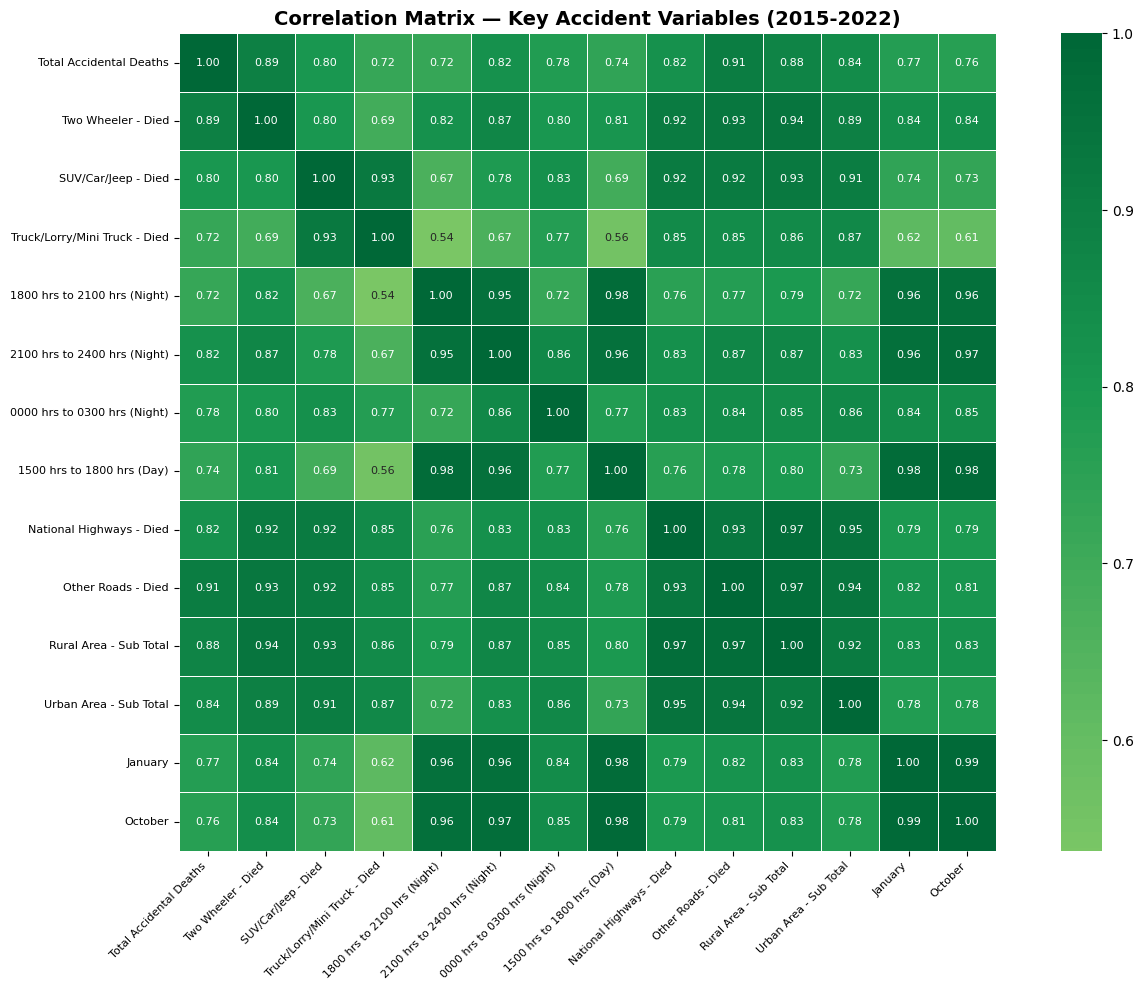


Top correlations with Total Accidental Deaths:
Other Roads - Died               0.912729
Two Wheeler - Died               0.893747
Rural Area - Sub Total           0.879980
Urban Area - Sub Total           0.843598
National Highways - Died         0.823634
2100 hrs to 2400 hrs (Night)     0.821558
SUV/Car/Jeep - Died              0.797694
0000 hrs to 0300 hrs (Night)     0.776031
January                          0.770034
October                          0.758212
1500 hrs to 1800 hrs (Day)       0.738812
1800 hrs to 2100 hrs (Night)     0.721335
Truck/Lorry/Mini Truck - Died    0.720274


In [3]:
# Correlation Analysis - Heatmap
# Select key columns for correlation
corr_cols = [
    "Total Accidental Deaths",
    "Two Wheeler - Died",
    "SUV/Car/Jeep - Died",
    "Truck/Lorry/Mini Truck - Died",
    "1800 hrs to 2100 hrs (Night)",
    "2100 hrs to 2400 hrs (Night)",
    "0000 hrs to 0300 hrs (Night)",
    "1500 hrs to 1800 hrs (Day)",
    "National Highways - Died",
    "Other Roads - Died",
    "Rural Area - Sub Total",
    "Urban Area - Sub Total",
    "January",
    "October"
]

corr_matrix = master_df[corr_cols].corr()

# Plot
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, 
            annot=True, 
            fmt=".2f", 
            cmap="RdYlGn",
            center=0,
            square=True,
            linewidths=0.5,
            annot_kws={"size": 8})

plt.title("Correlation Matrix — Key Accident Variables (2015-2022)", 
          fontsize=14, fontweight="bold")
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

# Print top correlations with Total Accidental Deaths
print("\nTop correlations with Total Accidental Deaths:")
corr_with_deaths = corr_matrix["Total Accidental Deaths"].drop("Total Accidental Deaths")
print(corr_with_deaths.sort_values(ascending=False).to_string())

Top 5 States: ['Maharashtra', 'Madhya Pradesh', 'Uttar Pradesh', 'Tamil Nadu', 'Rajasthan']


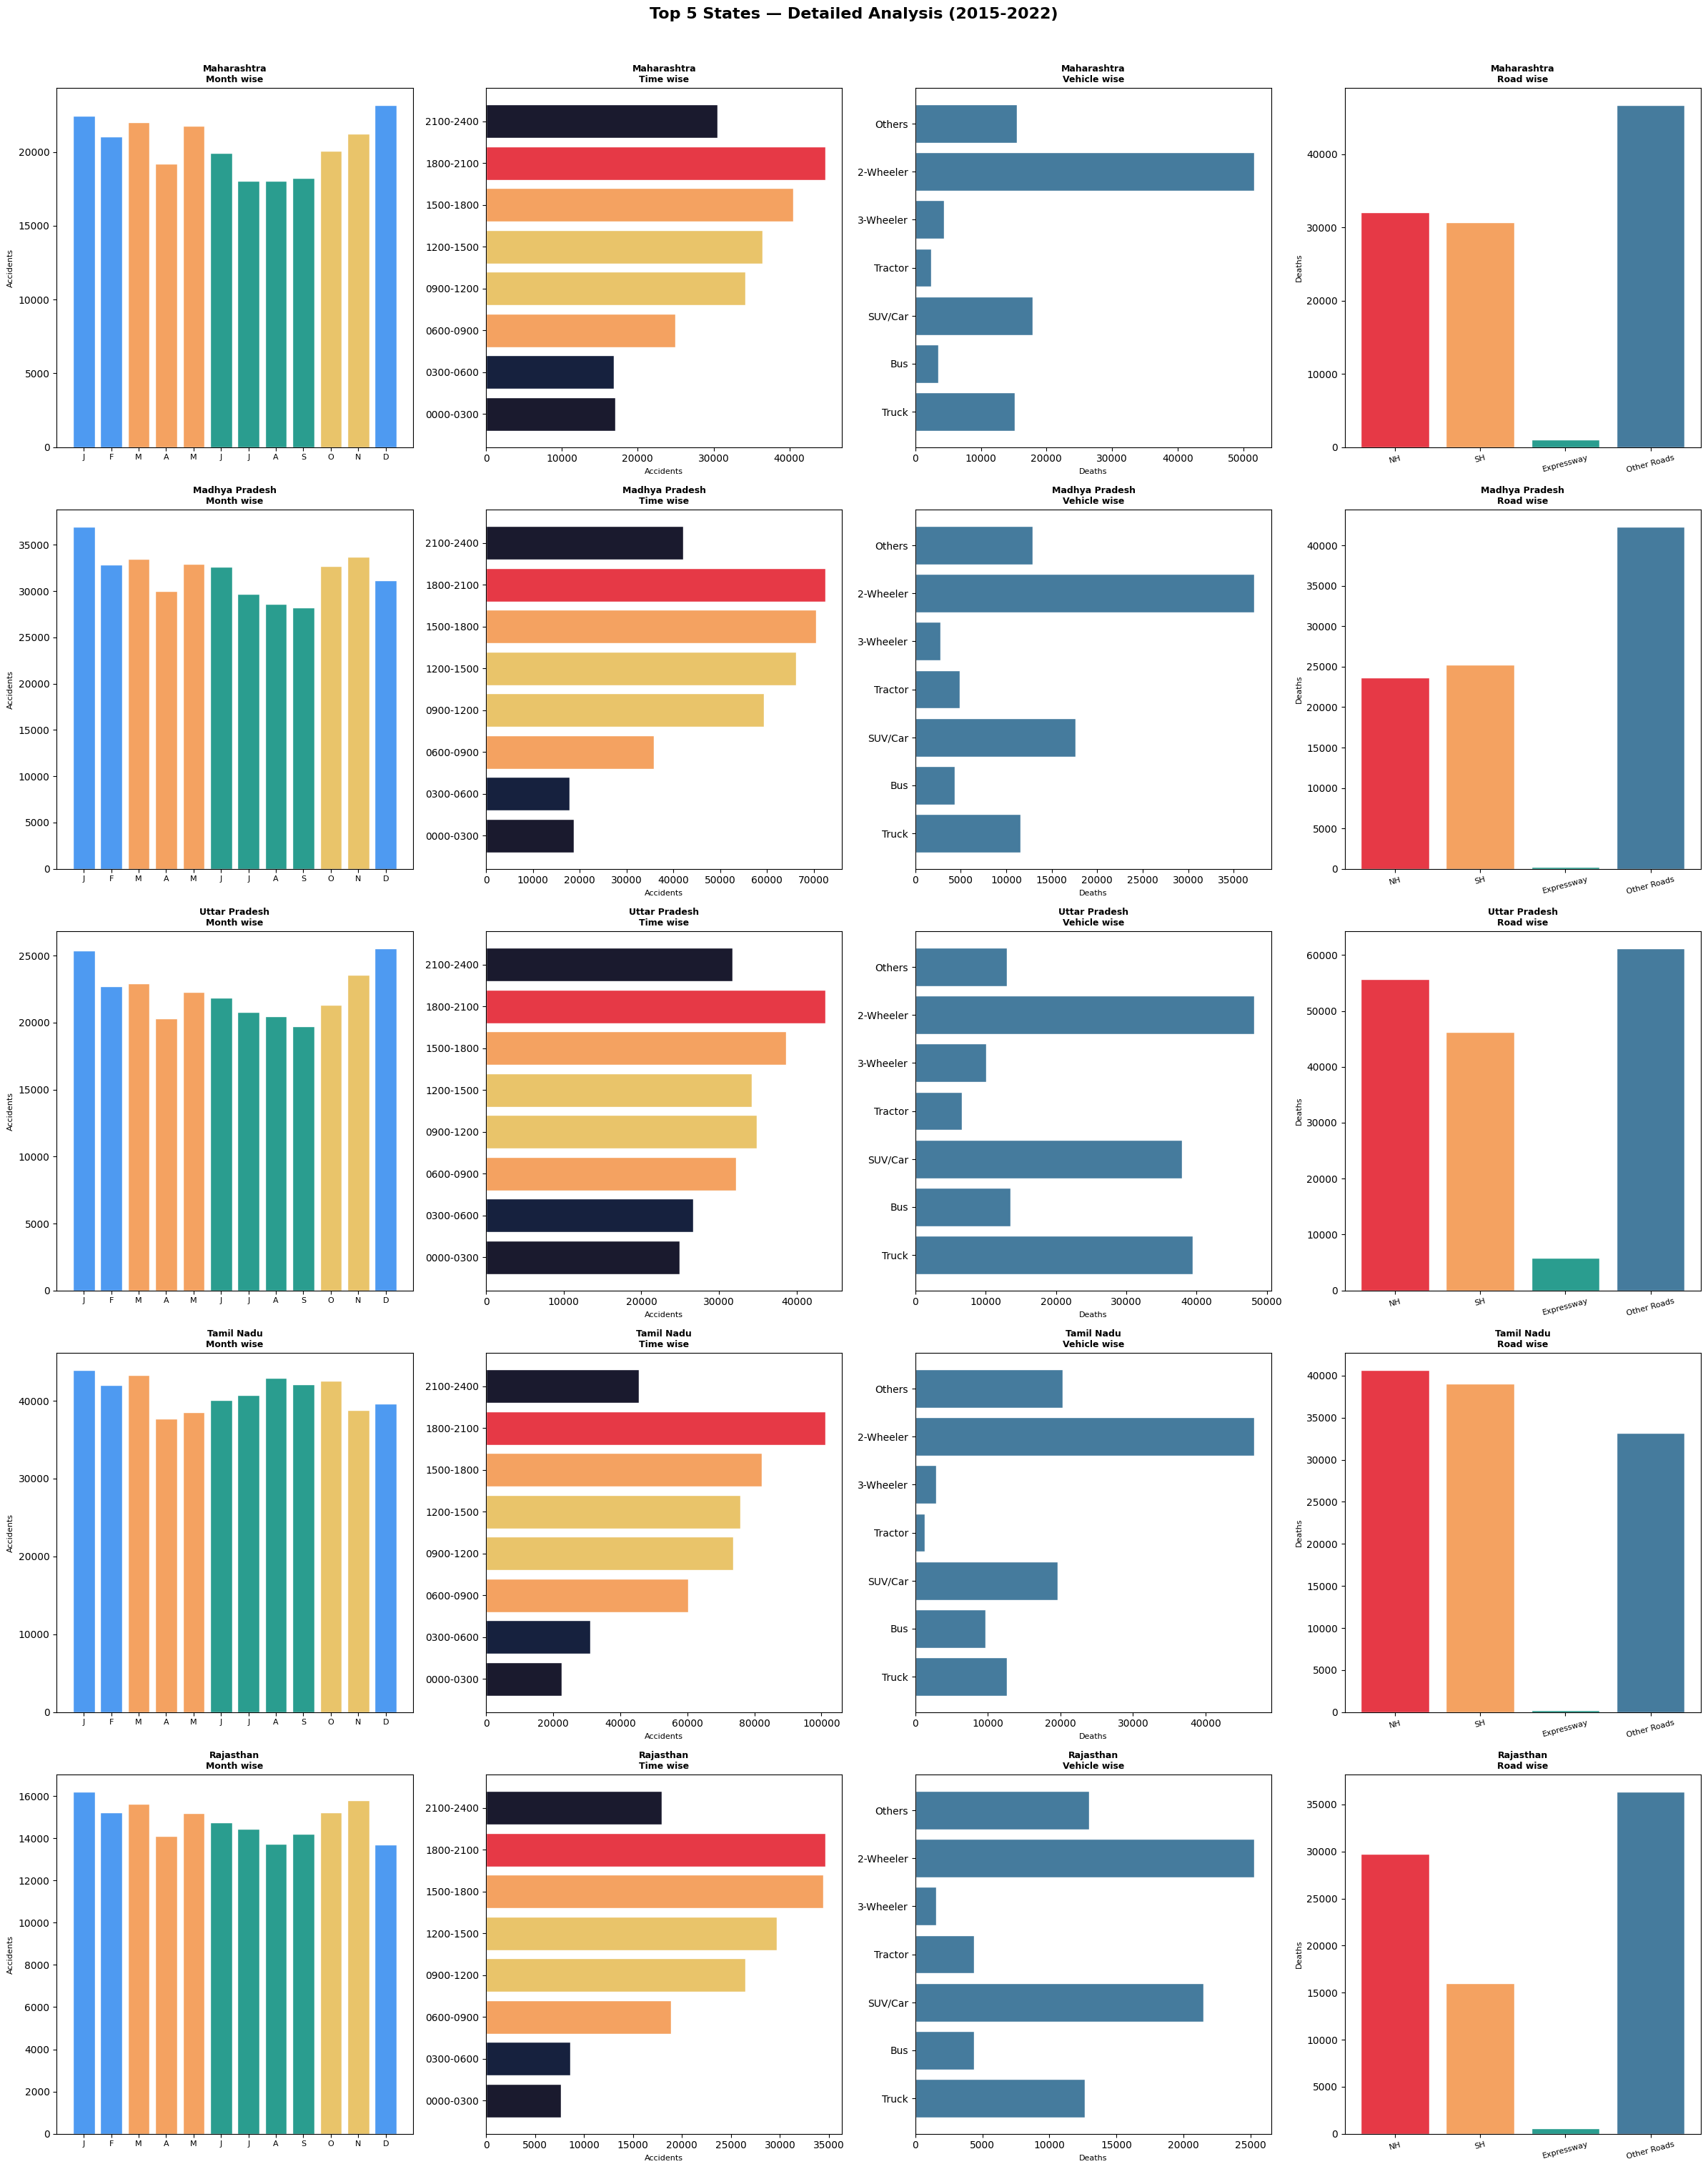


Top 5 States: ['Maharashtra', 'Madhya Pradesh', 'Uttar Pradesh', 'Tamil Nadu', 'Rajasthan']


In [4]:
# Analysis 2 - State wise Deep Dive (Top 5 States)
top5_states = deaths_df.groupby("State/UT")["Total Accidental Deaths"].mean()\
              .sort_values(ascending=False).head(5).index.tolist()

print(f"Top 5 States: {top5_states}")

# Filter master_df for top 5
top5_df = master_df[master_df["State/UT"].isin(top5_states)]

# Plot - 4 subplots per state
fig, axes = plt.subplots(5, 4, figsize=(24, 30))

month_cols = ["January", "February", "March", "April", "May", "June",
              "July", "August", "September", "October", "November", "December"]

time_cols = ["0000 hrs to 0300 hrs (Night)", "0300 hrs to 0600 hrs (Night)",
             "0600 hrs to 0900 hrs (Day)", "0900 hrs to 1200 hrs (Day)",
             "1200 hrs to 1500 hrs (Day)", "1500 hrs to 1800 hrs (Day)",
             "1800 hrs to 2100 hrs (Night)", "2100 hrs to 2400 hrs (Night)"]

vehicle_cols = ["Truck/Lorry/Mini Truck - Died", "Bus - Died", "SUV/Car/Jeep - Died",
                "Tractor - Died", "Three Wheeler/Auto Rickshaw - Died",
                "Two Wheeler - Died", "Other Motor Vehicles - Died"]

road_cols = ["National Highways - Died", "State Highways - Died",
             "Expressways - Died", "Other Roads - Died"]

for i, state in enumerate(top5_states):
    state_df = top5_df[top5_df["State/UT"] == state]
    
    # Chart 1 - Month wise
    month_data = state_df[month_cols].sum()
    axes[i, 0].bar(range(12), month_data.values, 
                   color=["#4e9af1"]*2 + ["#f4a261"]*3 + ["#2a9d8f"]*4 + ["#e9c46a"]*2 + ["#4e9af1"],
                   edgecolor="white")
    axes[i, 0].set_xticks(range(12))
    axes[i, 0].set_xticklabels(["J","F","M","A","M","J","J","A","S","O","N","D"], fontsize=8)
    axes[i, 0].set_title(f"{state}\nMonth wise", fontsize=9, fontweight="bold")
    axes[i, 0].set_ylabel("Accidents", fontsize=8)

    # Chart 2 - Time wise
    time_data = state_df[time_cols].sum()
    time_labels = ["0000-0300", "0300-0600", "0600-0900", "0900-1200",
                   "1200-1500", "1500-1800", "1800-2100", "2100-2400"]
    colors_time = ["#1a1a2e", "#16213e", "#f4a261", "#e9c46a",
                   "#e9c46a", "#f4a261", "#e63946", "#1a1a2e"]
    axes[i, 1].barh(time_labels, time_data.values, color=colors_time, edgecolor="white")
    axes[i, 1].set_title(f"{state}\nTime wise", fontsize=9, fontweight="bold")
    axes[i, 1].set_xlabel("Accidents", fontsize=8)

    # Chart 3 - Vehicle wise
    vehicle_data = state_df[vehicle_cols].sum()
    vehicle_labels = ["Truck", "Bus", "SUV/Car", "Tractor", "3-Wheeler", "2-Wheeler", "Others"]
    axes[i, 2].barh(vehicle_labels, vehicle_data.values, color="#457b9d", edgecolor="white")
    axes[i, 2].set_title(f"{state}\nVehicle wise", fontsize=9, fontweight="bold")
    axes[i, 2].set_xlabel("Deaths", fontsize=8)

    # Chart 4 - Road wise
    road_data = state_df[road_cols].sum()
    road_labels = ["NH", "SH", "Expressway", "Other Roads"]
    axes[i, 3].bar(road_labels, road_data.values, 
                   color=["#e63946", "#f4a261", "#2a9d8f", "#457b9d"],
                   edgecolor="white")
    axes[i, 3].set_title(f"{state}\nRoad wise", fontsize=9, fontweight="bold")
    axes[i, 3].set_ylabel("Deaths", fontsize=8)
    axes[i, 3].tick_params(axis='x', rotation=15, labelsize=8)

plt.suptitle("Top 5 States — Detailed Analysis (2015-2022)", 
             fontsize=16, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

print(f"\nTop 5 States: {top5_states}")

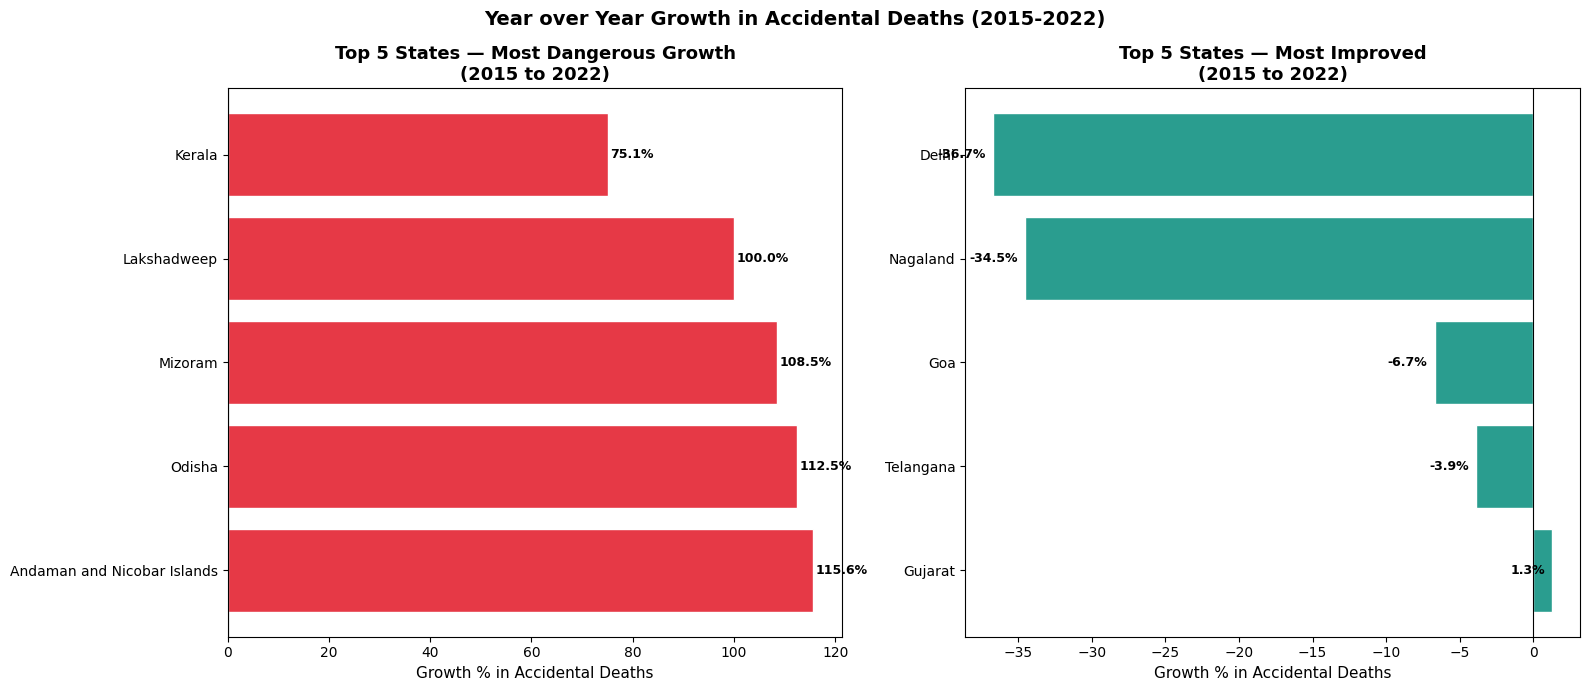


All States Growth %:
                                State/UT  Deaths 2015  Deaths 2022  Growth %
             Andaman and Nicobar Islands           96          207    115.62
                                  Odisha         9887        21013    112.53
                                 Mizoram          153          319    108.50
                             Lakshadweep            4            8    100.00
                                  Kerala         8635        15119     75.09
                                  Sikkim          183          310     69.40
                                   Bihar         9470        16025     69.22
                               Jharkhand         4819         7772     61.28
                               Meghalaya          369          590     59.89
                                 Tripura          399          635     59.15
                                 Haryana        10408        16041     54.12
                                 Manipur          240 

In [5]:
# Analysis 3 - Year over Year Growth
# Calculate growth % from 2015 to 2022 for each state
deaths_2015 = deaths_df[deaths_df["Year"] == 2015].set_index("State/UT")["Total Accidental Deaths"]
deaths_2022 = deaths_df[deaths_df["Year"] == 2022].set_index("State/UT")["Total Accidental Deaths"]

growth_df = pd.DataFrame({
    "Deaths 2015": deaths_2015,
    "Deaths 2022": deaths_2022
}).dropna()

growth_df["Growth %"] = ((growth_df["Deaths 2022"] - growth_df["Deaths 2015"]) / 
                          growth_df["Deaths 2015"] * 100).round(2)

growth_df = growth_df.sort_values("Growth %", ascending=False).reset_index()

# Top 5 growing and Top 5 improving
top5_growing = growth_df.head(5)
top5_improving = growth_df.tail(5)

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Top 5 growing
bars1 = ax1.barh(top5_growing["State/UT"], top5_growing["Growth %"],
                 color="#e63946", edgecolor="white")
for bar, val in zip(bars1, top5_growing["Growth %"]):
    ax1.text(val + 0.5, bar.get_y() + bar.get_height()/2,
             f"{val:.1f}%", va="center", fontsize=9, fontweight="bold")
ax1.set_title("Top 5 States — Most Dangerous Growth\n(2015 to 2022)",
              fontsize=13, fontweight="bold")
ax1.set_xlabel("Growth % in Accidental Deaths", fontsize=11)
ax1.axvline(x=0, color="black", linewidth=0.8)

# Top 5 improving
bars2 = ax2.barh(top5_improving["State/UT"], top5_improving["Growth %"],
                 color="#2a9d8f", edgecolor="white")
for bar, val in zip(bars2, top5_improving["Growth %"]):
    ax2.text(val - 0.5, bar.get_y() + bar.get_height()/2,
             f"{val:.1f}%", va="center", ha="right", fontsize=9, fontweight="bold")
ax2.set_title("Top 5 States — Most Improved\n(2015 to 2022)",
              fontsize=13, fontweight="bold")
ax2.set_xlabel("Growth % in Accidental Deaths", fontsize=11)
ax2.axvline(x=0, color="black", linewidth=0.8)

plt.suptitle("Year over Year Growth in Accidental Deaths (2015-2022)",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print("\nAll States Growth %:")
print(growth_df[["State/UT", "Deaths 2015", "Deaths 2022", "Growth %"]].to_string(index=False))

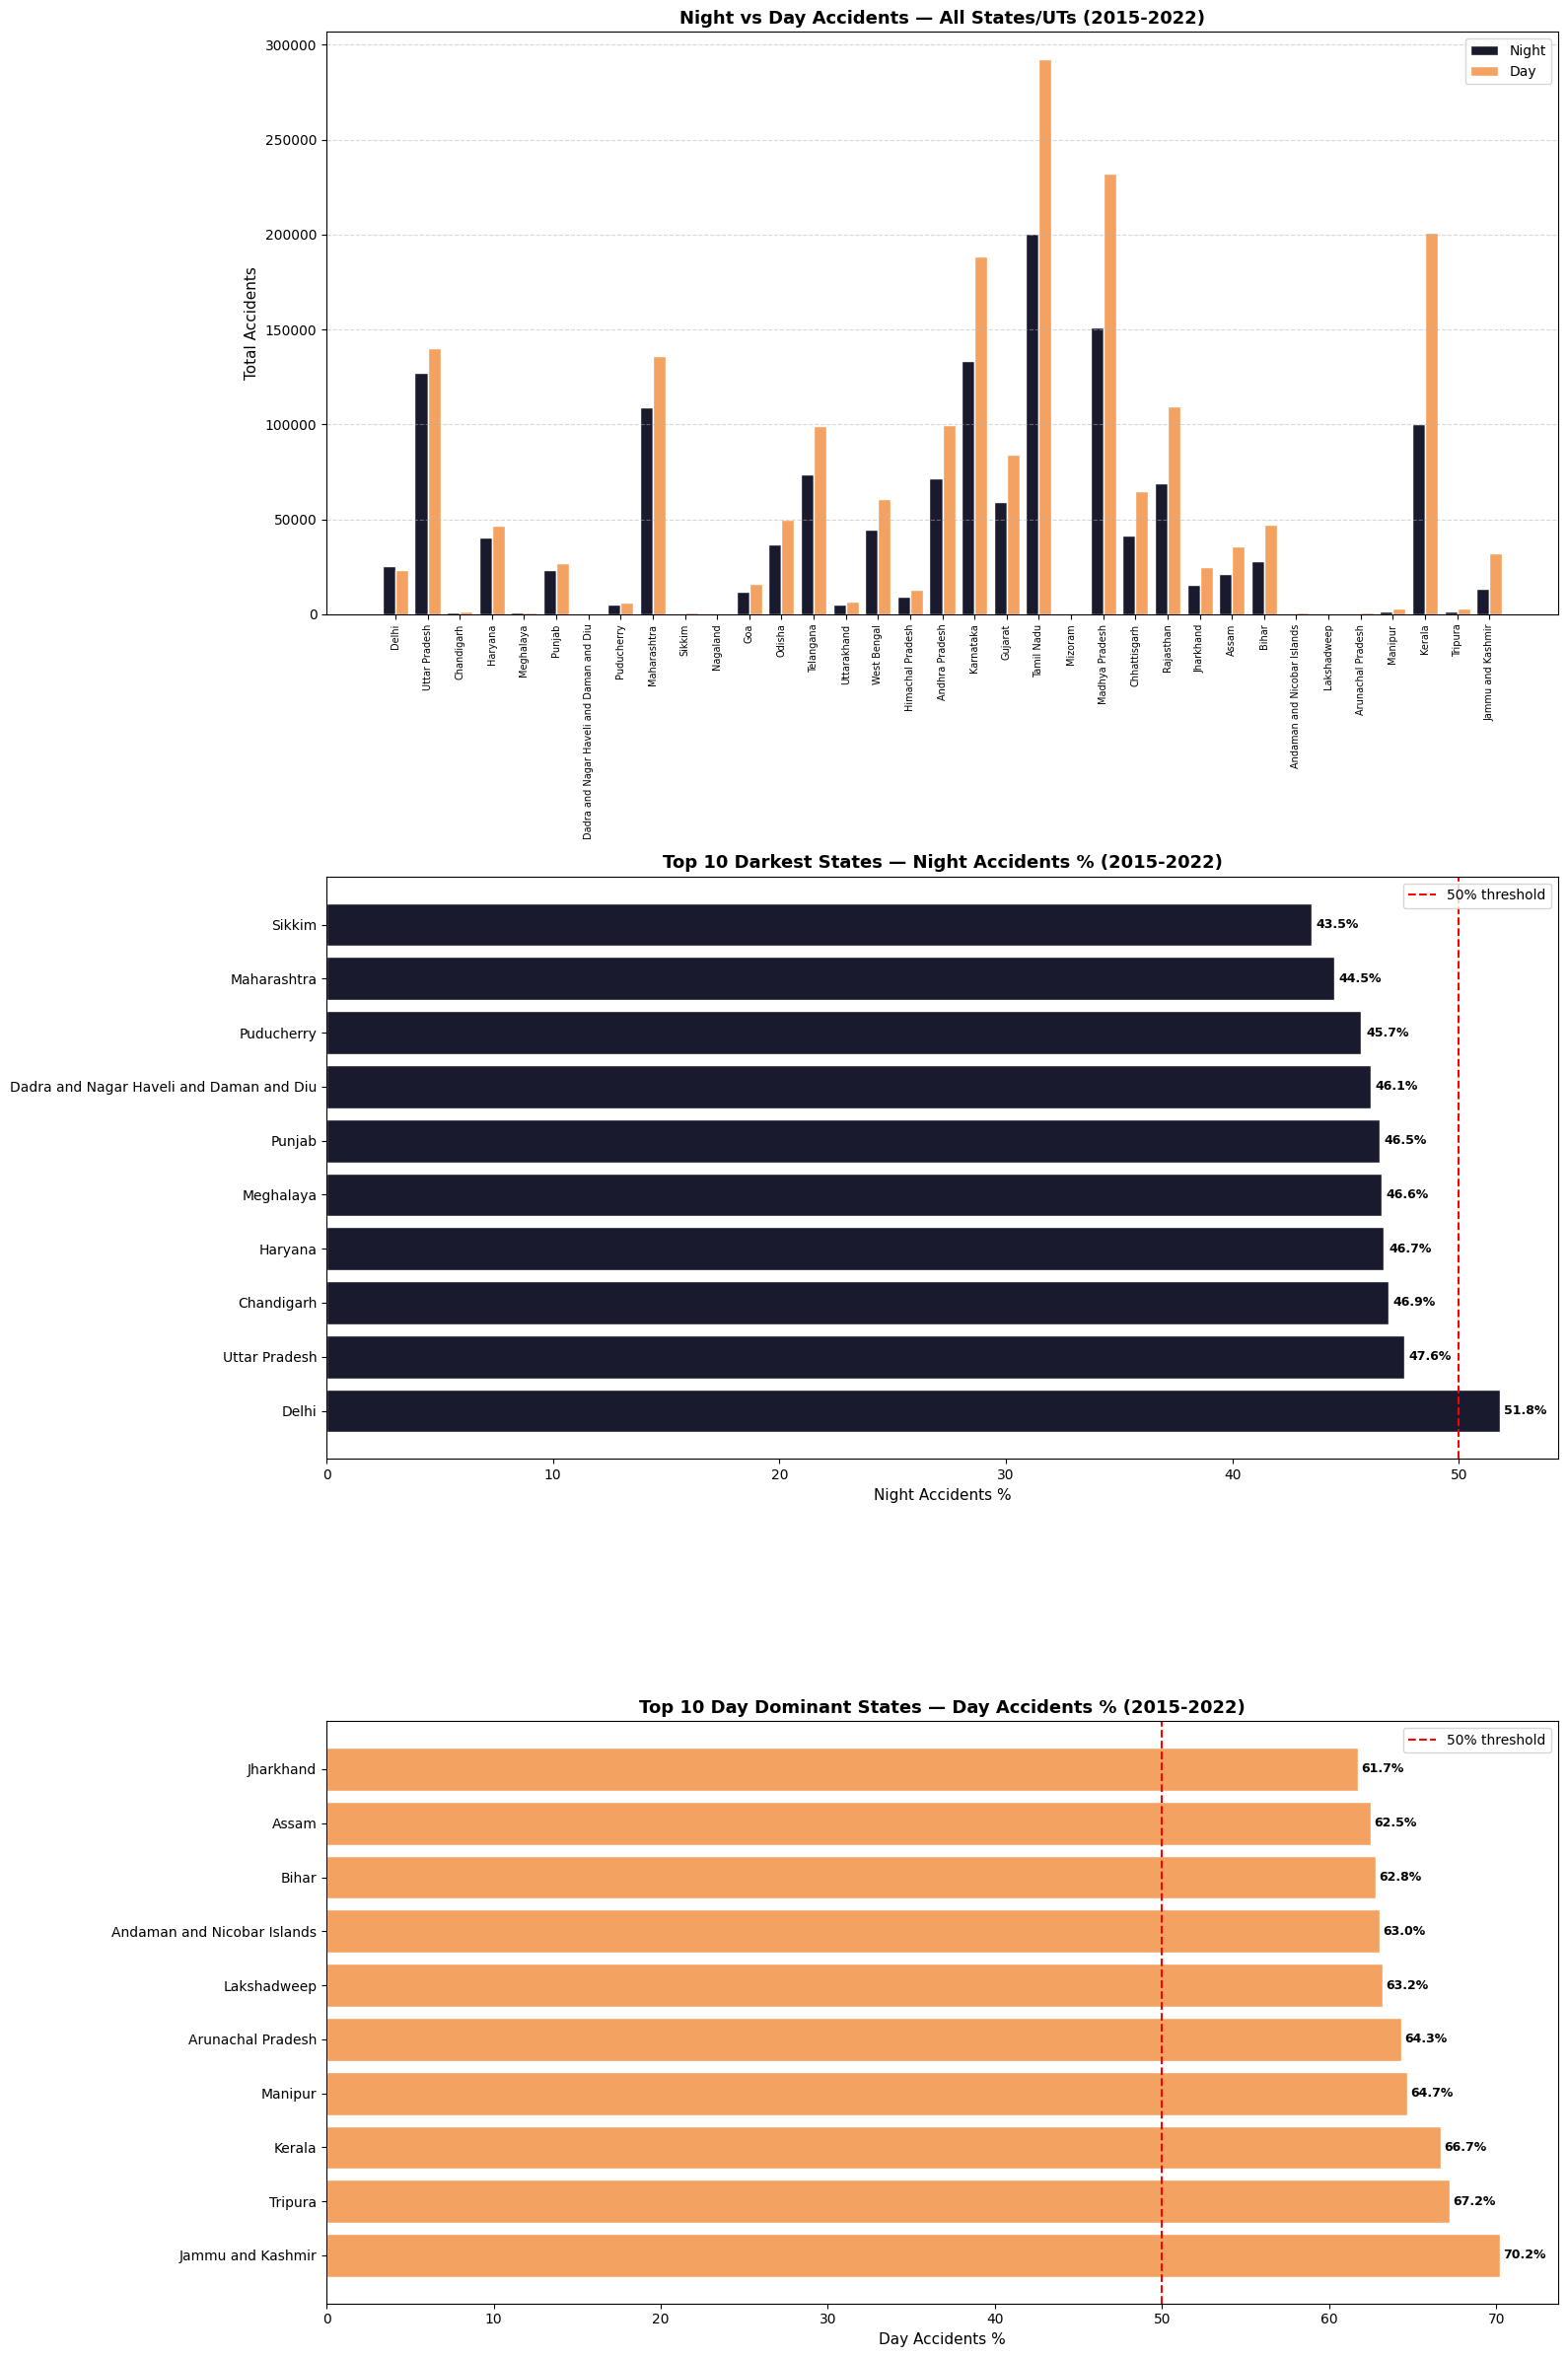


All States — Night vs Day:
                                State/UT  Total Night  Total Day  Night %  Day %
                                   Delhi        25248      23469     51.8   48.2
                           Uttar Pradesh       126972     139941     47.6   52.4
                              Chandigarh         1125       1274     46.9   53.1
                                 Haryana        40650      46442     46.7   53.3
                               Meghalaya         1016       1162     46.6   53.4
                                  Punjab        23289      26819     46.5   53.5
Dadra and Nagar Haveli and Daman and Diu          504        589     46.1   53.9
                              Puducherry         5102       6072     45.7   54.3
                             Maharashtra       109196     136144     44.5   55.5
                                  Sikkim          598        777     43.5   56.5
                                Nagaland          131        176     42.7   57.3


In [8]:
# Analysis 4 - Night vs Day Ratio - All States + Top 10 Darkest + Top 10 Day Dominant

# Define Night and Day columns
night_cols = [
    "0000 hrs to 0300 hrs (Night)",
    "0300 hrs to 0600 hrs (Night)",
    "1800 hrs to 2100 hrs (Night)",
    "2100 hrs to 2400 hrs (Night)"
]

day_cols = [
    "0600 hrs to 0900 hrs (Day)",
    "0900 hrs to 1200 hrs (Day)",
    "1200 hrs to 1500 hrs (Day)",
    "1500 hrs to 1800 hrs (Day)"
]

# Calculate Night and Day totals per state
state_time = time_df.groupby("State/UT")[night_cols + day_cols].sum()
state_time["Total Night"] = state_time[night_cols].sum(axis=1)
state_time["Total Day"] = state_time[day_cols].sum(axis=1)
state_time["Night/Day Ratio"] = (state_time["Total Night"] / state_time["Total Day"]).round(3)
state_time["Night %"] = (state_time["Total Night"] / 
                          (state_time["Total Night"] + state_time["Total Day"]) * 100).round(1)
state_time = state_time.reset_index().sort_values("Night %", ascending=False)

# Top 10 darkest and day dominant
top10_dark = state_time.head(10)
top10_day = state_time.tail(10).sort_values("Night %", ascending=True)

# Plot — 3 charts
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(16, 24))

# Chart 1 — All States Night vs Day
x = range(len(state_time))
width = 0.4
ax1.bar([i - width/2 for i in x], state_time["Total Night"],
        width=width, label="Night", color="#1a1a2e", edgecolor="white")
ax1.bar([i + width/2 for i in x], state_time["Total Day"],
        width=width, label="Day", color="#f4a261", edgecolor="white")
ax1.set_xticks(list(x))
ax1.set_xticklabels(state_time["State/UT"], rotation=90, fontsize=7)
ax1.set_title("Night vs Day Accidents — All States/UTs (2015-2022)",
              fontsize=13, fontweight="bold")
ax1.set_ylabel("Total Accidents", fontsize=11)
ax1.legend(fontsize=10)
ax1.grid(axis="y", linestyle="--", alpha=0.5)

# Chart 2 — Top 10 Darkest States
bars2 = ax2.barh(top10_dark["State/UT"], top10_dark["Night %"],
                 color="#1a1a2e", edgecolor="white")
for bar, val in zip(bars2, top10_dark["Night %"]):
    ax2.text(val + 0.2, bar.get_y() + bar.get_height()/2,
             f"{val}%", va="center", fontsize=9, fontweight="bold")
ax2.axvline(x=50, color="red", linewidth=1.5, linestyle="--", label="50% threshold")
ax2.set_title("Top 10 Darkest States — Night Accidents % (2015-2022)",
              fontsize=13, fontweight="bold")
ax2.set_xlabel("Night Accidents %", fontsize=11)
ax2.legend(fontsize=10)

# Chart 3 — Top 10 Day Dominant States
day_vals = 100 - top10_day["Night %"]
bars3 = ax3.barh(top10_day["State/UT"], day_vals,
                 color="#f4a261", edgecolor="white")
for bar, val in zip(bars3, day_vals):
    ax3.text(val + 0.2, bar.get_y() + bar.get_height()/2,
             f"{val:.1f}%", va="center", fontsize=9, fontweight="bold")
ax3.axvline(x=50, color="red", linewidth=1.5, linestyle="--", label="50% threshold")
ax3.set_title("Top 10 Day Dominant States — Day Accidents % (2015-2022)",
              fontsize=13, fontweight="bold")
ax3.set_xlabel("Day Accidents %", fontsize=11)
ax3.legend(fontsize=10)

plt.tight_layout()
plt.show()

print("\nAll States — Night vs Day:")
print(state_time[["State/UT", "Total Night", "Total Day", "Night %"]]\
      .assign(**{"Day %": lambda x: (100 - x["Night %"]).round(1)})\
      .to_string(index=False))

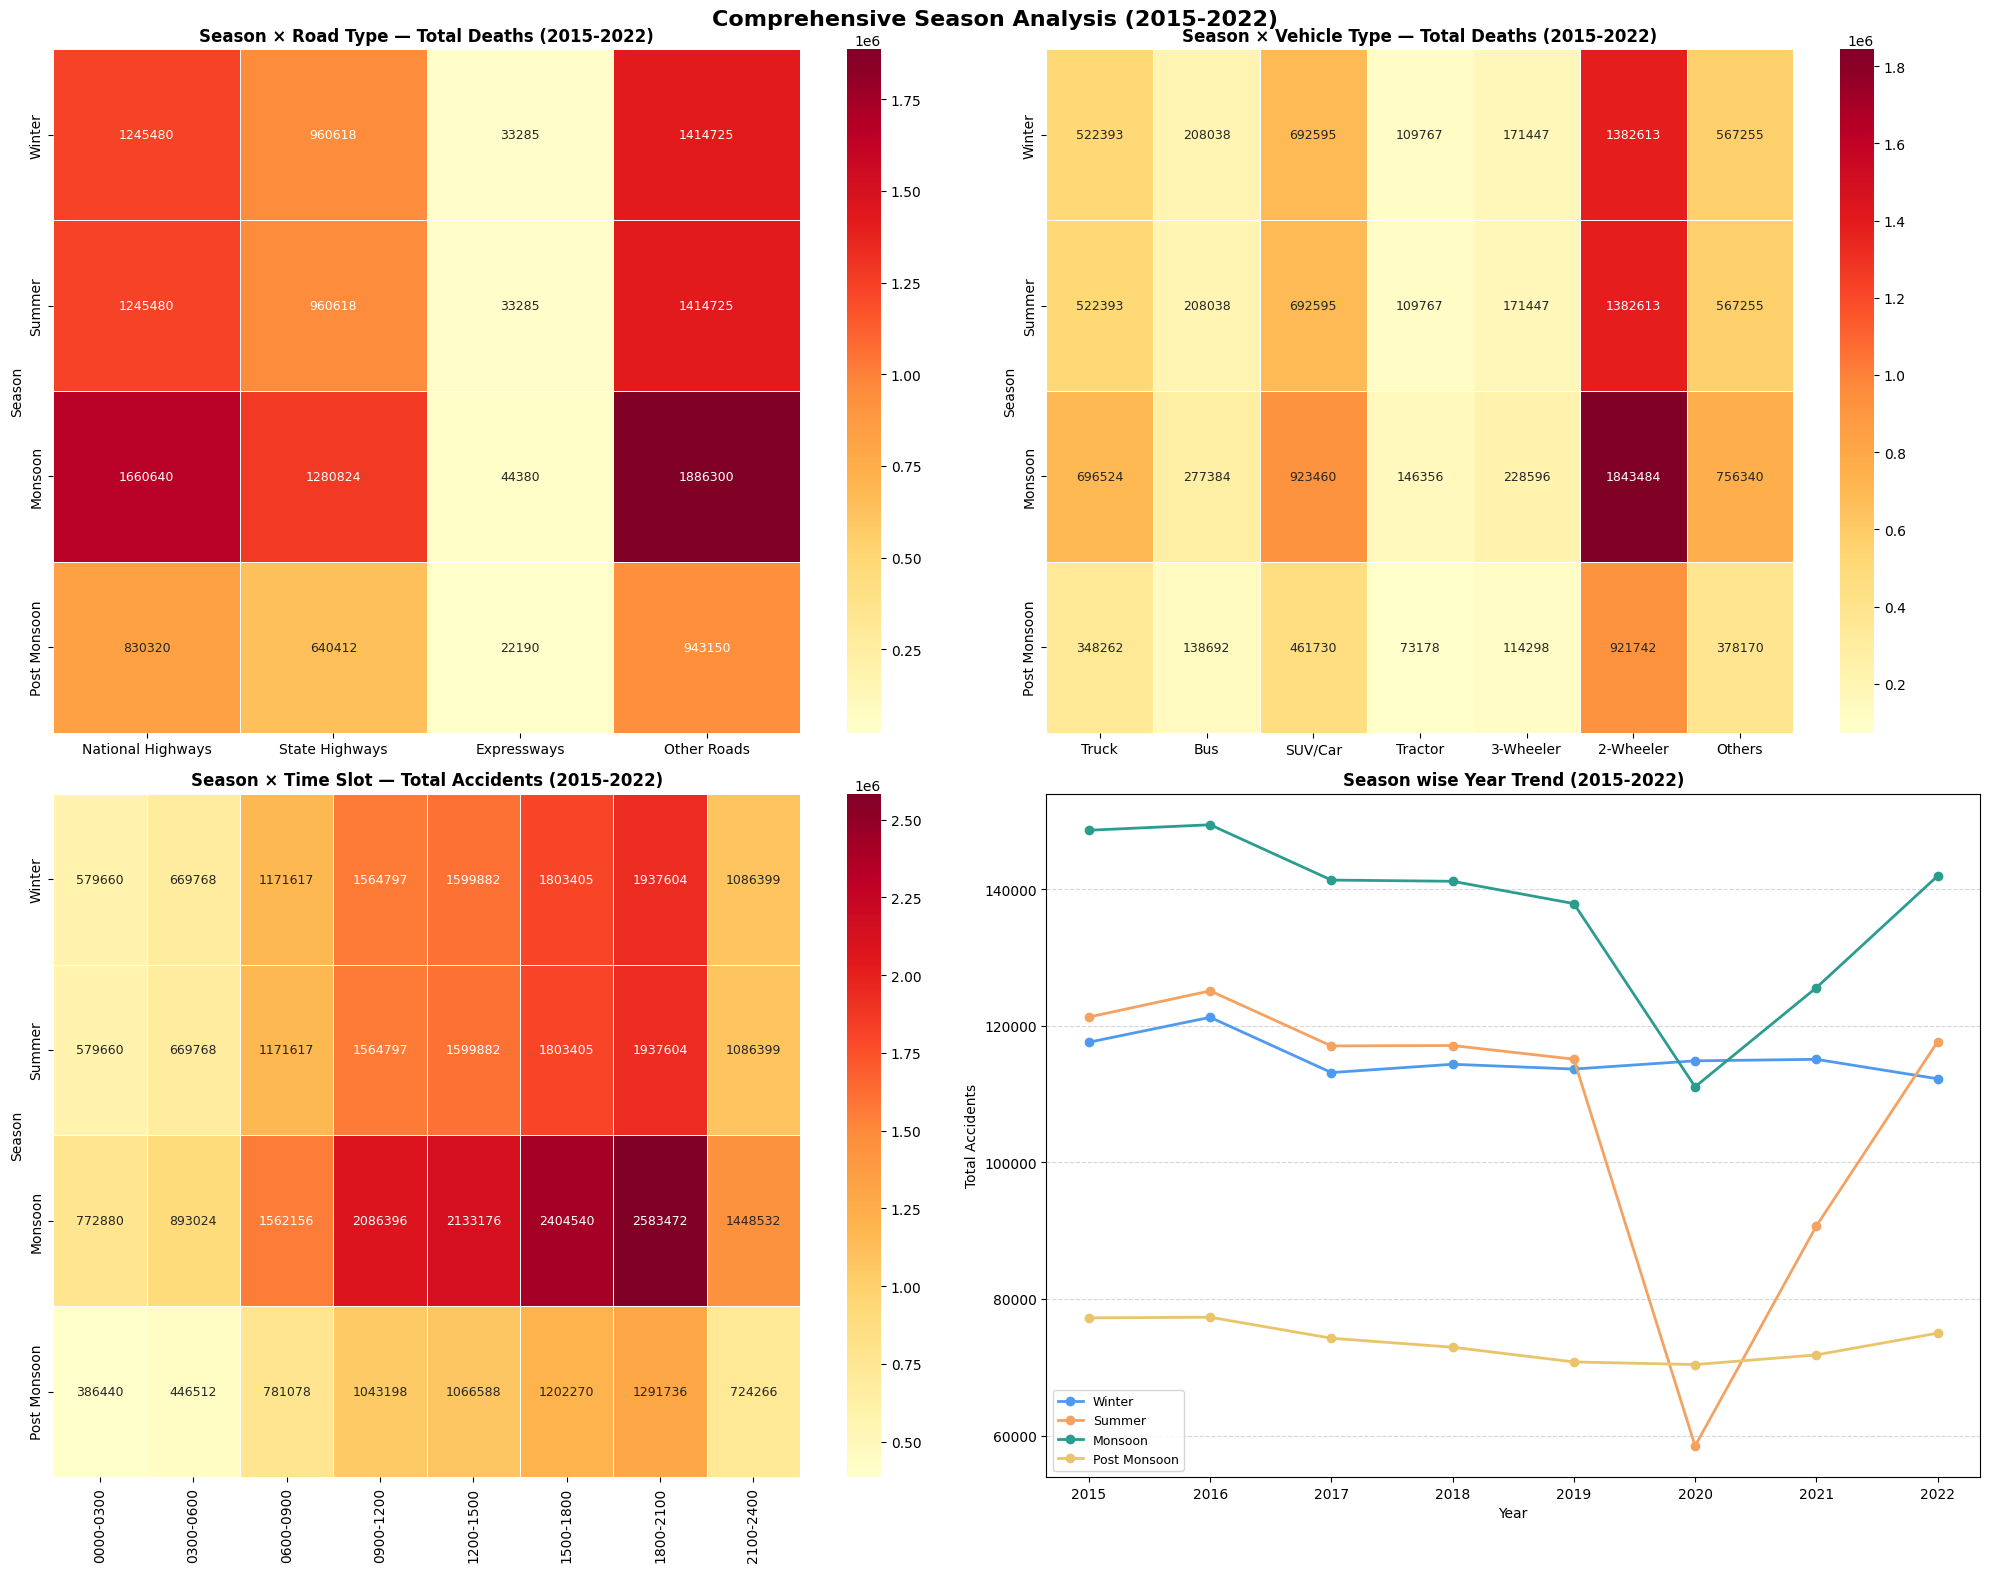

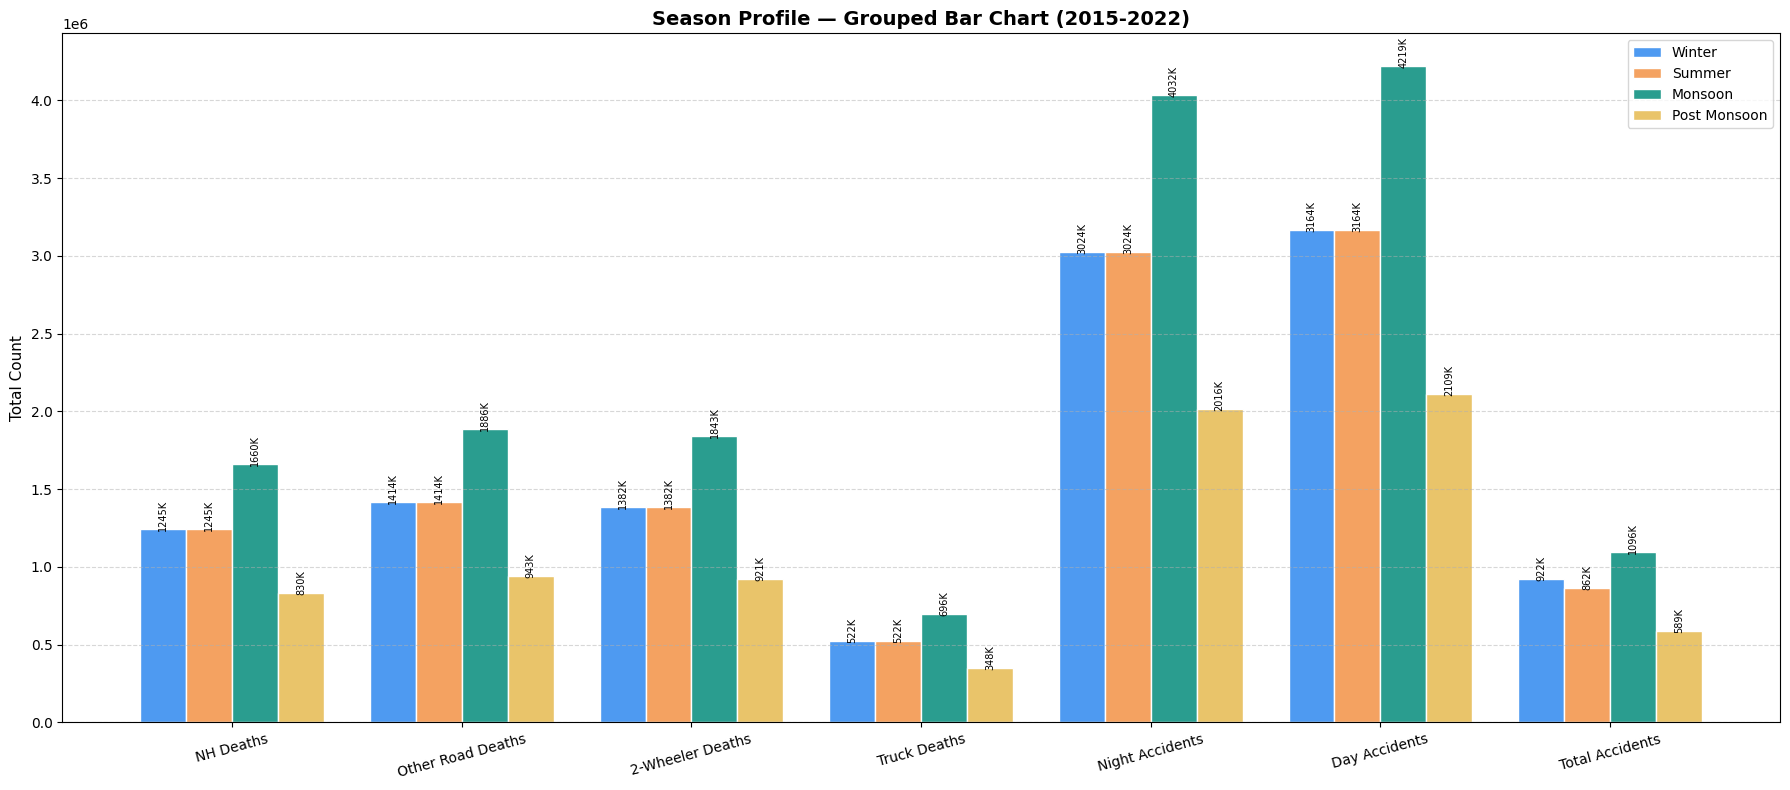


Season × Road Type:
              National Highways  State Highways  Expressways  Other Roads
Season                                                                   
Winter                  1245480          960618        33285      1414725
Summer                  1245480          960618        33285      1414725
Monsoon                 1660640         1280824        44380      1886300
Post Monsoon             830320          640412        22190       943150

Season × Vehicle:
               Truck     Bus  SUV/Car  Tractor  3-Wheeler  2-Wheeler  Others
Season                                                                      
Winter        522393  208038   692595   109767     171447    1382613  567255
Summer        522393  208038   692595   109767     171447    1382613  567255
Monsoon       696524  277384   923460   146356     228596    1843484  756340
Post Monsoon  348262  138692   461730    73178     114298     921742  378170

Season × Time:
              0000-0300  0300-0600  06

In [11]:
# Analysis 5 - Comprehensive Season Analysis + Grouped Bar Chart

# Define seasons
def get_season(month):
    if month in ["December", "January", "February"]:
        return "Winter"
    elif month in ["March", "April", "May"]:
        return "Summer"
    elif month in ["June", "July", "August", "September"]:
        return "Monsoon"
    else:
        return "Post Monsoon"

month_cols = ["January", "February", "March", "April", "May", "June",
              "July", "August", "September", "October", "November", "December"]

month_long = month_df.melt(
    id_vars=["S.No.", "State/UT", "Year"],
    value_vars=month_cols,
    var_name="Month",
    value_name="Accidents"
)
month_long["Season"] = month_long["Month"].apply(get_season)

season_master = month_long.merge(
    road_df, on=["S.No.", "State/UT", "Year"], how="left"
).merge(
    transport_df, on=["S.No.", "State/UT", "Year"], how="left"
).merge(
    time_df, on=["S.No.", "State/UT", "Year"], how="left"
)

season_order = ["Winter", "Summer", "Monsoon", "Post Monsoon"]
season_colors = {"Winter": "#4e9af1", "Summer": "#f4a261",
                 "Monsoon": "#2a9d8f", "Post Monsoon": "#e9c46a"}

road_type_cols = ["National Highways - Died", "State Highways - Died",
                  "Expressways - Died", "Other Roads - Died"]
vehicle_cols = ["Truck/Lorry/Mini Truck - Died", "Bus - Died", "SUV/Car/Jeep - Died",
                "Tractor - Died", "Three Wheeler/Auto Rickshaw - Died",
                "Two Wheeler - Died", "Other Motor Vehicles - Died"]
time_slot_cols = ["0000 hrs to 0300 hrs (Night)", "0300 hrs to 0600 hrs (Night)",
                  "0600 hrs to 0900 hrs (Day)", "0900 hrs to 1200 hrs (Day)",
                  "1200 hrs to 1500 hrs (Day)", "1500 hrs to 1800 hrs (Day)",
                  "1800 hrs to 2100 hrs (Night)", "2100 hrs to 2400 hrs (Night)"]

season_road = season_master.groupby("Season")[road_type_cols].sum()
season_road.index = pd.CategoricalIndex(season_road.index, categories=season_order, ordered=True)
season_road = season_road.sort_index()
season_road.columns = ["National Highways", "State Highways", "Expressways", "Other Roads"]

season_vehicle = season_master.groupby("Season")[vehicle_cols].sum()
season_vehicle.index = pd.CategoricalIndex(season_vehicle.index, categories=season_order, ordered=True)
season_vehicle = season_vehicle.sort_index()
season_vehicle.columns = ["Truck", "Bus", "SUV/Car", "Tractor", "3-Wheeler", "2-Wheeler", "Others"]

season_time = season_master.groupby("Season")[time_slot_cols].sum()
season_time.index = pd.CategoricalIndex(season_time.index, categories=season_order, ordered=True)
season_time = season_time.sort_index()
season_time.columns = ["0000-0300", "0300-0600", "0600-0900", "0900-1200",
                        "1200-1500", "1500-1800", "1800-2100", "2100-2400"]

season_year = season_master.groupby(["Year", "Season"])["Accidents"].sum().reset_index()

# ============================================================
# PART 1 - Original 4 Charts
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(20, 16))

sns.heatmap(season_road, annot=True, fmt=".0f", cmap="YlOrRd",
            ax=axes[0, 0], linewidths=0.5, annot_kws={"size": 9})
axes[0, 0].set_title("Season × Road Type — Total Deaths (2015-2022)",
                      fontsize=12, fontweight="bold")

sns.heatmap(season_vehicle, annot=True, fmt=".0f", cmap="YlOrRd",
            ax=axes[0, 1], linewidths=0.5, annot_kws={"size": 9})
axes[0, 1].set_title("Season × Vehicle Type — Total Deaths (2015-2022)",
                      fontsize=12, fontweight="bold")

sns.heatmap(season_time, annot=True, fmt=".0f", cmap="YlOrRd",
            ax=axes[1, 0], linewidths=0.5, annot_kws={"size": 9})
axes[1, 0].set_title("Season × Time Slot — Total Accidents (2015-2022)",
                      fontsize=12, fontweight="bold")

for season in season_order:
    data = season_year[season_year["Season"] == season]
    axes[1, 1].plot(data["Year"], data["Accidents"],
                    marker="o", linewidth=2,
                    label=season, color=season_colors[season])
axes[1, 1].set_title("Season wise Year Trend (2015-2022)",
                      fontsize=12, fontweight="bold")
axes[1, 1].set_xlabel("Year", fontsize=10)
axes[1, 1].set_ylabel("Total Accidents", fontsize=10)
axes[1, 1].legend(fontsize=9)
axes[1, 1].set_xticks(range(2015, 2023))
axes[1, 1].grid(axis="y", linestyle="--", alpha=0.5)

plt.suptitle("Comprehensive Season Analysis (2015-2022)",
             fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

# ============================================================
# PART 2 - Grouped Bar Chart — Season Profile
# ============================================================
radar_metrics = {
    "NH Deaths": season_road["National Highways"],
    "Other Road Deaths": season_road["Other Roads"],
    "2-Wheeler Deaths": season_vehicle["2-Wheeler"],
    "Truck Deaths": season_vehicle["Truck"],
    "Night Accidents": season_time["1800-2100"] + season_time["2100-2400"],
    "Day Accidents": season_time["0900-1200"] + season_time["1200-1500"],
    "Total Accidents": season_master.groupby("Season")["Accidents"].sum()
}

radar_df = pd.DataFrame(radar_metrics)
radar_df.index = pd.CategoricalIndex(radar_df.index, categories=season_order, ordered=True)
radar_df = radar_df.sort_index()

metrics = list(radar_df.columns)
seasons = list(radar_df.index)
x = np.arange(len(metrics))
width = 0.2

fig, ax = plt.subplots(figsize=(18, 8))

for i, season in enumerate(seasons):
    bars = ax.bar(x + i * width, radar_df.loc[season],
                  width=width, label=season,
                  color=list(season_colors.values())[i],
                  edgecolor="white")

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(metrics, fontsize=10, rotation=15)
ax.set_title("Season Profile — Grouped Bar Chart (2015-2022)",
             fontsize=14, fontweight="bold")
ax.set_ylabel("Total Count", fontsize=11)
ax.legend(fontsize=10)
ax.grid(axis="y", linestyle="--", alpha=0.5)

for i, season in enumerate(seasons):
    for j, val in enumerate(radar_df.loc[season]):
        ax.text(j + i * width, val + 1000,
                f"{int(val/1000)}K",
                ha="center", fontsize=7, rotation=90)

plt.tight_layout()
plt.show()

print("\nSeason × Road Type:")
print(season_road.to_string())
print("\nSeason × Vehicle:")
print(season_vehicle.to_string())
print("\nSeason × Time:")
print(season_time.to_string())

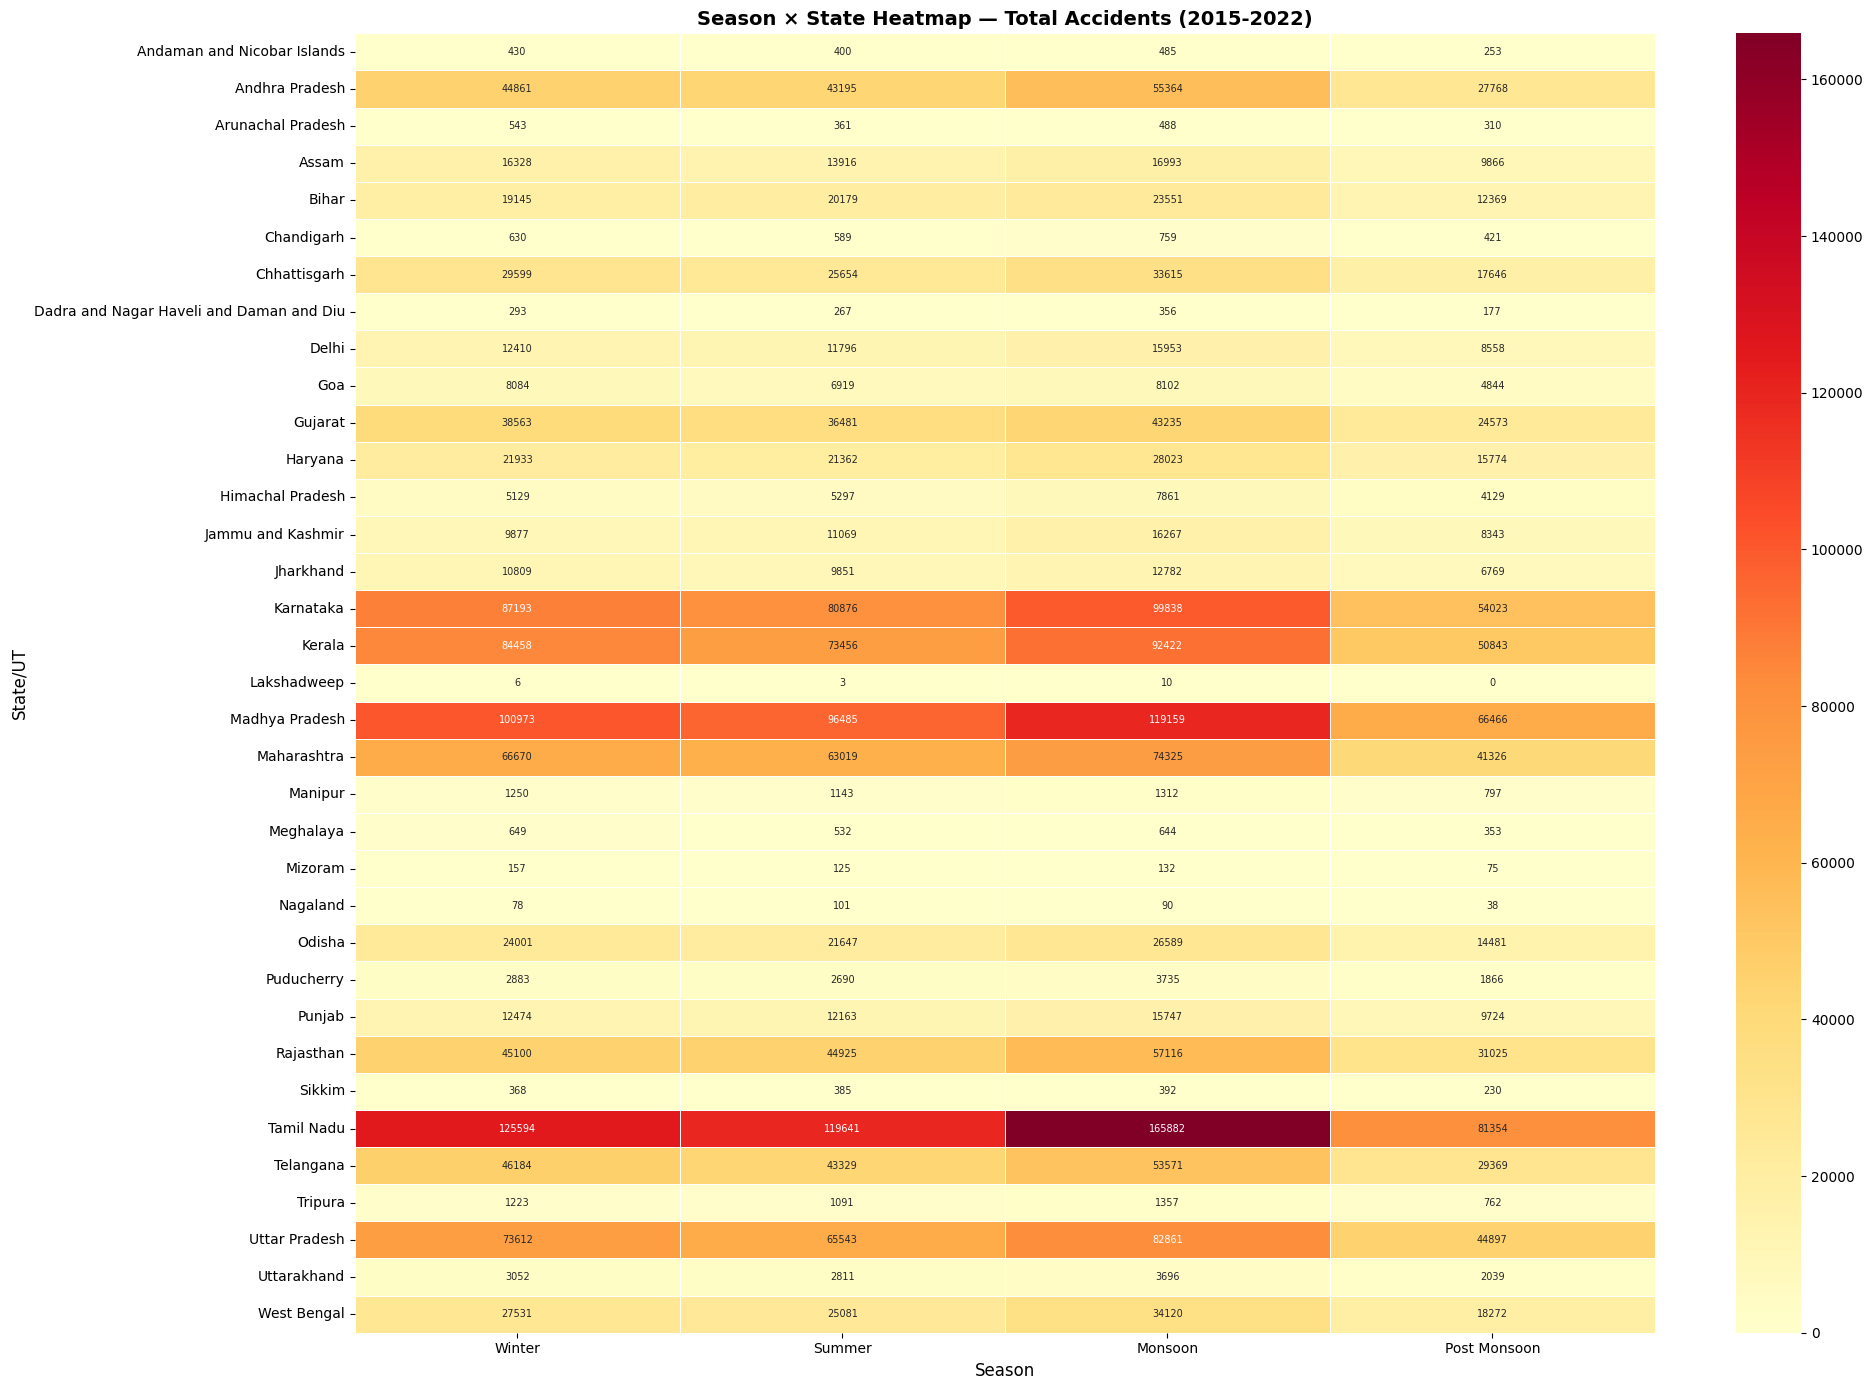

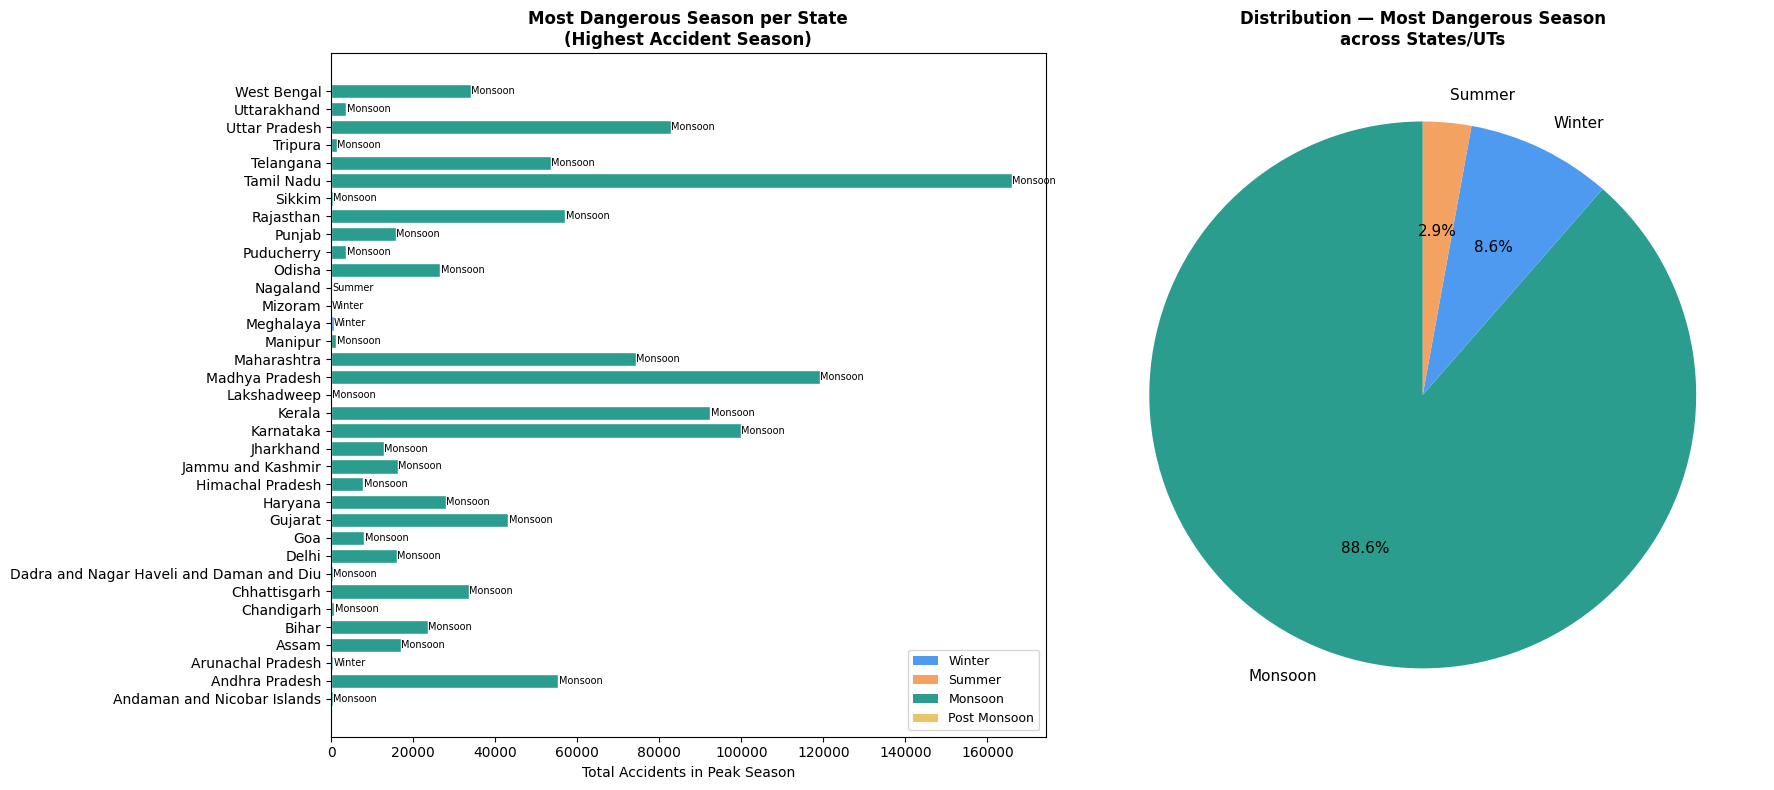

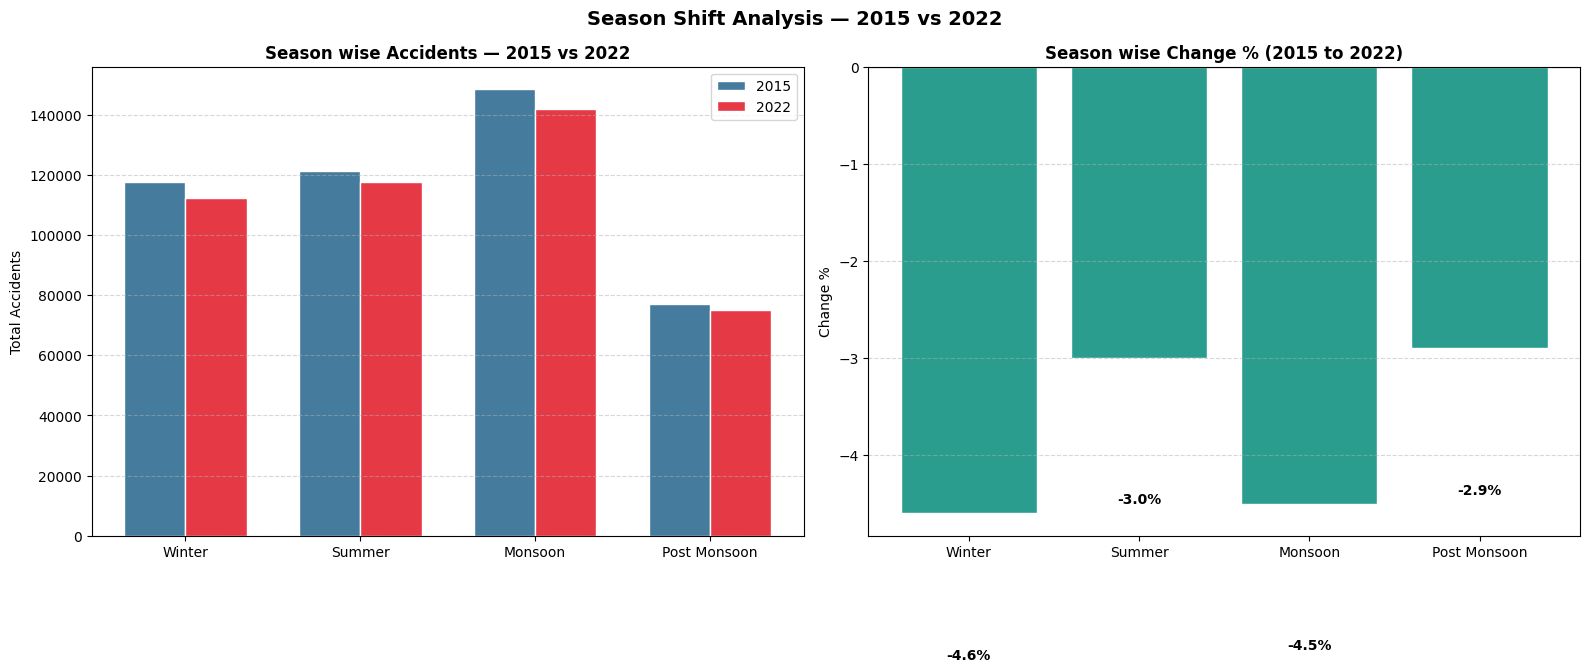


Season Shift:
                2015    2022  Change %
Season                                
Winter        117578  112228      -4.6
Summer        121263  117640      -3.0
Monsoon       148602  141905      -4.5
Post Monsoon   77231   74995      -2.9


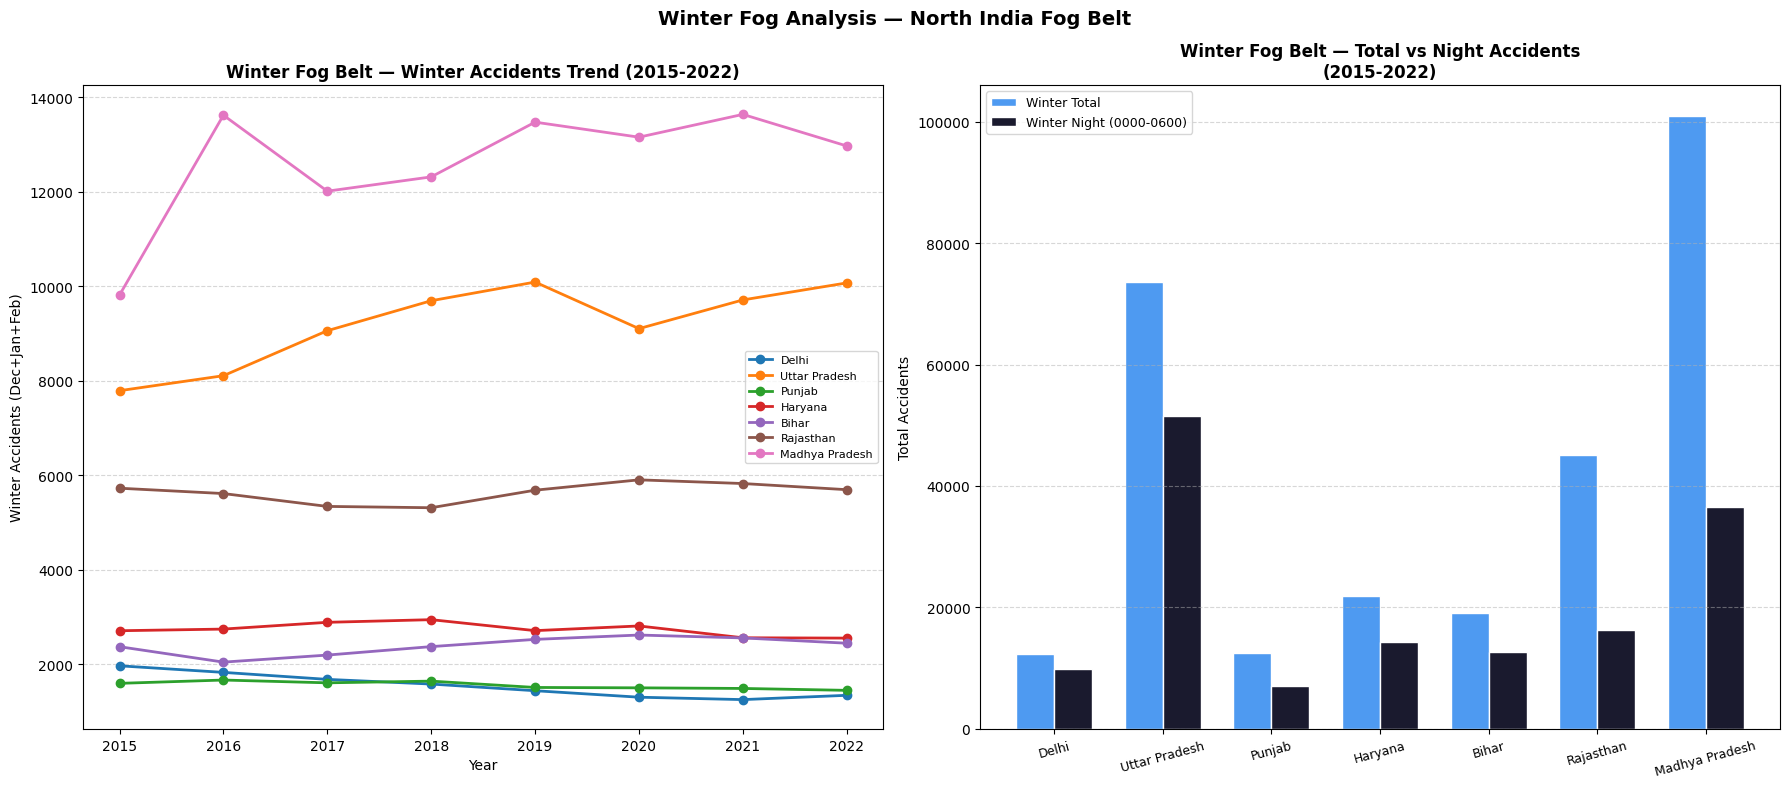

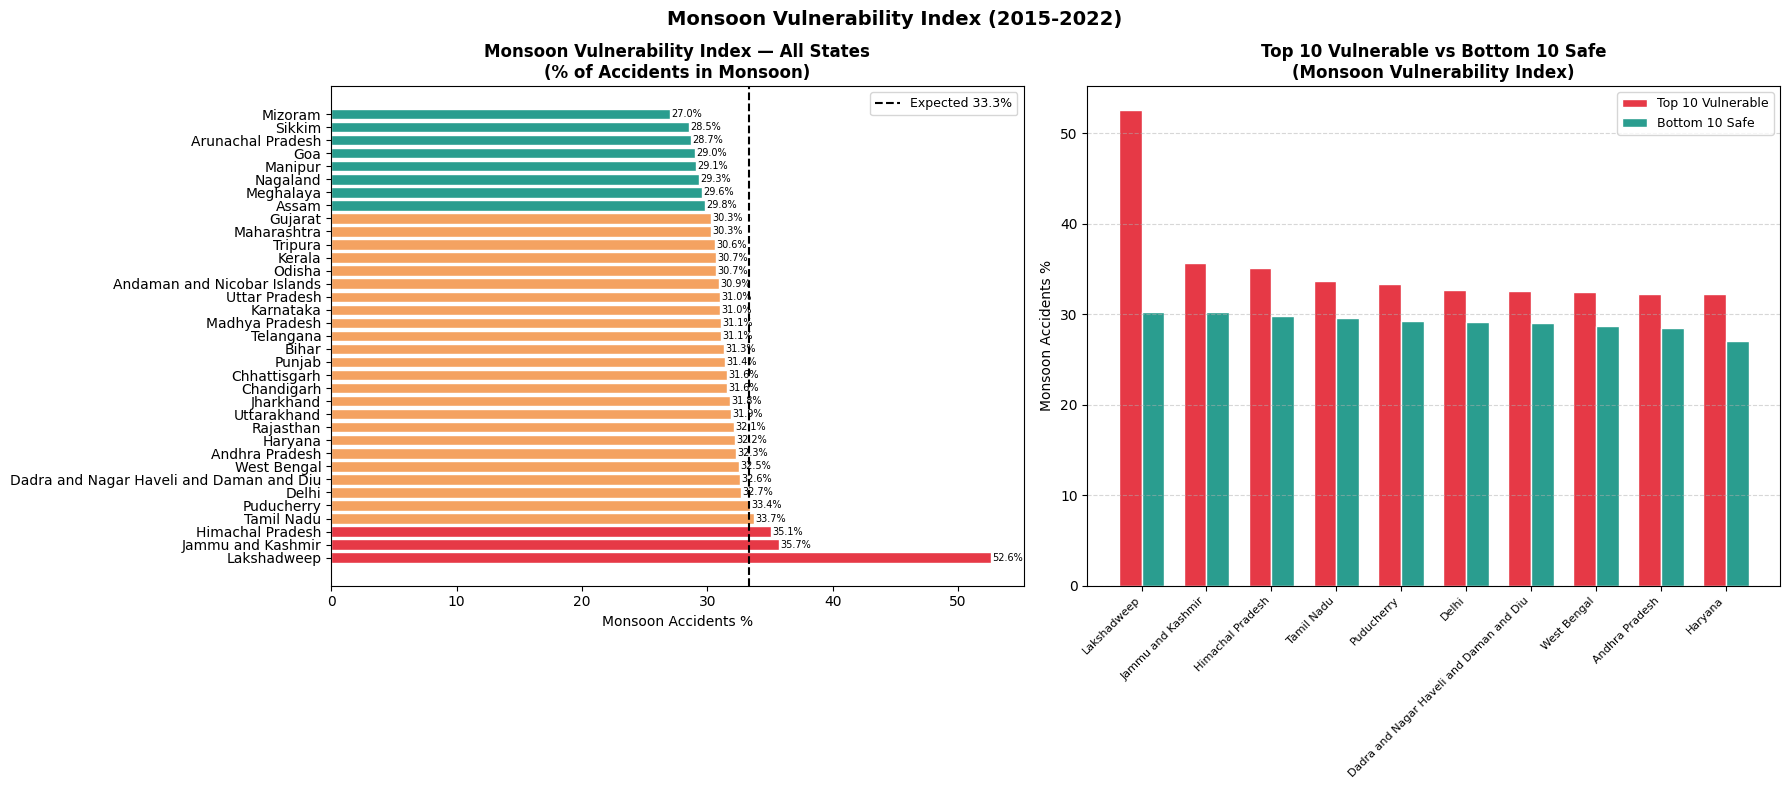


Monsoon Vulnerability Index — Top 10:
                                State/UT  Monsoon Total  Non Monsoon Total  Monsoon Vulnerability Index
                             Lakshadweep             10                  9                         52.6
                       Jammu and Kashmir          16267              29289                         35.7
                        Himachal Pradesh           7861              14555                         35.1
                              Tamil Nadu         165882             326589                         33.7
                              Puducherry           3735               7439                         33.4
                                   Delhi          15953              32764                         32.7
Dadra and Nagar Haveli and Daman and Diu            356                737                         32.6
                             West Bengal          34120              70884                         32.5
                         

In [12]:
# Analysis 5 - Extended Season Analysis

# ============================================================
# PART 3 - Season × State Heatmap
# ============================================================
season_state = season_master.groupby(["State/UT", "Season"])["Accidents"].sum().unstack()
season_state = season_state[season_order]

plt.figure(figsize=(20, 14))
sns.heatmap(season_state, annot=True, fmt=".0f", cmap="YlOrRd",
            linewidths=0.5, annot_kws={"size": 7})
plt.title("Season × State Heatmap — Total Accidents (2015-2022)",
          fontsize=14, fontweight="bold")
plt.xlabel("Season", fontsize=12)
plt.ylabel("State/UT", fontsize=12)
plt.tight_layout()
plt.show()

# ============================================================
# PART 4 - Most Dangerous Season per State
# ============================================================
most_dangerous_season = season_state.idxmax(axis=1).reset_index()
most_dangerous_season.columns = ["State/UT", "Most Dangerous Season"]

season_count = most_dangerous_season["Most Dangerous Season"].value_counts()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

# Bar chart — states grouped by dangerous season
colors_map = most_dangerous_season["Most Dangerous Season"].map(season_colors)
bars = ax1.barh(most_dangerous_season["State/UT"], 
                season_state.max(axis=1).values,
                color=colors_map, edgecolor="white")
ax1.set_title("Most Dangerous Season per State\n(Highest Accident Season)",
              fontsize=12, fontweight="bold")
ax1.set_xlabel("Total Accidents in Peak Season", fontsize=10)

# Add season labels
for bar, season in zip(bars, most_dangerous_season["Most Dangerous Season"]):
    ax1.text(bar.get_width() + 100, bar.get_y() + bar.get_height()/2,
             season, va="center", fontsize=7)

# Pie chart — how many states per dangerous season
ax2.pie(season_count.values, labels=season_count.index,
        colors=[season_colors[s] for s in season_count.index],
        autopct="%1.1f%%", startangle=90, textprops={"fontsize": 11})
ax2.set_title("Distribution — Most Dangerous Season\nacross States/UTs",
              fontsize=12, fontweight="bold")

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=season_colors[s], label=s) for s in season_order]
ax1.legend(handles=legend_elements, fontsize=9, loc="lower right")

plt.tight_layout()
plt.show()

# ============================================================
# PART 5 - Season Shift Analysis (2015 vs 2022)
# ============================================================
season_2015 = season_master[season_master["Year"] == 2015].groupby("Season")["Accidents"].sum()
season_2022 = season_master[season_master["Year"] == 2022].groupby("Season")["Accidents"].sum()

season_shift = pd.DataFrame({
    "2015": season_2015,
    "2022": season_2022
})
season_shift.index = pd.CategoricalIndex(season_shift.index, categories=season_order, ordered=True)
season_shift = season_shift.sort_index()
season_shift["Change %"] = ((season_shift["2022"] - season_shift["2015"]) / 
                             season_shift["2015"] * 100).round(1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Grouped bar — 2015 vs 2022
x = np.arange(len(season_order))
width = 0.35
ax1.bar(x - width/2, season_shift["2015"], width=width, 
        label="2015", color="#457b9d", edgecolor="white")
ax1.bar(x + width/2, season_shift["2022"], width=width,
        label="2022", color="#e63946", edgecolor="white")
ax1.set_xticks(x)
ax1.set_xticklabels(season_order, fontsize=10)
ax1.set_title("Season wise Accidents — 2015 vs 2022",
              fontsize=12, fontweight="bold")
ax1.set_ylabel("Total Accidents", fontsize=10)
ax1.legend(fontsize=10)
ax1.grid(axis="y", linestyle="--", alpha=0.5)

# Change % bar
colors_change = ["#e63946" if x > 0 else "#2a9d8f" for x in season_shift["Change %"]]
bars = ax2.bar(season_order, season_shift["Change %"],
               color=colors_change, edgecolor="white")
for bar, val in zip(bars, season_shift["Change %"]):
    ax2.text(bar.get_x() + bar.get_width()/2,
             val + 0.5 if val > 0 else val - 1.5,
             f"{val}%", ha="center", fontsize=10, fontweight="bold")
ax2.axhline(y=0, color="black", linewidth=0.8)
ax2.set_title("Season wise Change % (2015 to 2022)",
              fontsize=12, fontweight="bold")
ax2.set_ylabel("Change %", fontsize=10)
ax2.grid(axis="y", linestyle="--", alpha=0.5)

plt.suptitle("Season Shift Analysis — 2015 vs 2022",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print("\nSeason Shift:")
print(season_shift.to_string())

# ============================================================
# PART 6 - Winter Fog Analysis — North India Fog Belt
# ============================================================
fog_states = ["Delhi", "Uttar Pradesh", "Punjab", "Haryana", 
              "Bihar", "Rajasthan", "Madhya Pradesh"]

fog_df = master_df[master_df["State/UT"].isin(fog_states)].copy()

# Winter months + Night slots
fog_df["Winter Fog Accidents"] = (
    fog_df["December"] + fog_df["January"] + fog_df["February"]
)
fog_df["Winter Night Accidents"] = (
    fog_df["0000 hrs to 0300 hrs (Night)"] +
    fog_df["0300 hrs to 0600 hrs (Night)"]
)

fog_yearly = fog_df.groupby(["Year", "State/UT"])[
    ["Winter Fog Accidents", "Winter Night Accidents"]].sum().reset_index()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

# Line chart — Winter Fog Accidents per state year wise
for state in fog_states:
    data = fog_yearly[fog_yearly["State/UT"] == state]
    ax1.plot(data["Year"], data["Winter Fog Accidents"],
             marker="o", linewidth=2, label=state)
ax1.set_title("Winter Fog Belt — Winter Accidents Trend (2015-2022)",
              fontsize=12, fontweight="bold")
ax1.set_xlabel("Year", fontsize=10)
ax1.set_ylabel("Winter Accidents (Dec+Jan+Feb)", fontsize=10)
ax1.legend(fontsize=8)
ax1.set_xticks(range(2015, 2023))
ax1.grid(axis="y", linestyle="--", alpha=0.5)

# Bar chart — Winter Night Accidents by state
fog_state_total = fog_df.groupby("State/UT")[["Winter Fog Accidents", "Winter Night Accidents"]].sum()
x = np.arange(len(fog_states))
width = 0.35
ax2.bar(x - width/2, fog_state_total.loc[fog_states, "Winter Fog Accidents"],
        width=width, label="Winter Total", color="#4e9af1", edgecolor="white")
ax2.bar(x + width/2, fog_state_total.loc[fog_states, "Winter Night Accidents"],
        width=width, label="Winter Night (0000-0600)", color="#1a1a2e", edgecolor="white")
ax2.set_xticks(x)
ax2.set_xticklabels(fog_states, rotation=15, fontsize=9)
ax2.set_title("Winter Fog Belt — Total vs Night Accidents\n(2015-2022)",
              fontsize=12, fontweight="bold")
ax2.set_ylabel("Total Accidents", fontsize=10)
ax2.legend(fontsize=9)
ax2.grid(axis="y", linestyle="--", alpha=0.5)

plt.suptitle("Winter Fog Analysis — North India Fog Belt",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# ============================================================
# PART 7 - Monsoon Vulnerability Index
# ============================================================
monsoon_months = ["June", "July", "August", "September"]
non_monsoon_months = ["October", "November", "December", "January", 
                       "February", "March", "April", "May"]

state_monsoon = month_df.copy()
state_monsoon["Monsoon Total"] = state_monsoon[monsoon_months].sum(axis=1)
state_monsoon["Non Monsoon Total"] = state_monsoon[non_monsoon_months].sum(axis=1)

monsoon_index = state_monsoon.groupby("State/UT")[
    ["Monsoon Total", "Non Monsoon Total"]].sum()
monsoon_index["Monsoon Vulnerability Index"] = (
    monsoon_index["Monsoon Total"] / 
    (monsoon_index["Monsoon Total"] + monsoon_index["Non Monsoon Total"]) * 100
).round(1)
monsoon_index = monsoon_index.sort_values("Monsoon Vulnerability Index", ascending=False).reset_index()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

# All states MVI
colors_mvi = ["#e63946" if x > 35 else "#f4a261" if x > 30 else "#2a9d8f" 
               for x in monsoon_index["Monsoon Vulnerability Index"]]
bars = ax1.barh(monsoon_index["State/UT"], 
                monsoon_index["Monsoon Vulnerability Index"],
                color=colors_mvi, edgecolor="white")
for bar, val in zip(bars, monsoon_index["Monsoon Vulnerability Index"]):
    ax1.text(val + 0.1, bar.get_y() + bar.get_height()/2,
             f"{val}%", va="center", fontsize=7)
ax1.axvline(x=33.3, color="black", linewidth=1.5, 
            linestyle="--", label="Expected 33.3%")
ax1.set_title("Monsoon Vulnerability Index — All States\n(% of Accidents in Monsoon)",
              fontsize=12, fontweight="bold")
ax1.set_xlabel("Monsoon Accidents %", fontsize=10)
ax1.legend(fontsize=9)

# Top 10 vs Bottom 10
top10_mvi = monsoon_index.head(10)
bottom10_mvi = monsoon_index.tail(10)

x = np.arange(10)
width = 0.35
ax2.bar(x - width/2, top10_mvi["Monsoon Vulnerability Index"],
        width=width, label="Top 10 Vulnerable", color="#e63946", edgecolor="white")
ax2.bar(x + width/2, bottom10_mvi["Monsoon Vulnerability Index"].values,
        width=width, label="Bottom 10 Safe", color="#2a9d8f", edgecolor="white")
ax2.set_xticks(x)
ax2.set_xticklabels(top10_mvi["State/UT"], rotation=45, fontsize=8, ha="right")
ax2.set_title("Top 10 Vulnerable vs Bottom 10 Safe\n(Monsoon Vulnerability Index)",
              fontsize=12, fontweight="bold")
ax2.set_ylabel("Monsoon Accidents %", fontsize=10)
ax2.legend(fontsize=9)
ax2.grid(axis="y", linestyle="--", alpha=0.5)

plt.suptitle("Monsoon Vulnerability Index (2015-2022)",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print("\nMonsoon Vulnerability Index — Top 10:")
print(monsoon_index.head(10)[["State/UT", "Monsoon Total", 
      "Non Monsoon Total", "Monsoon Vulnerability Index"]].to_string(index=False))

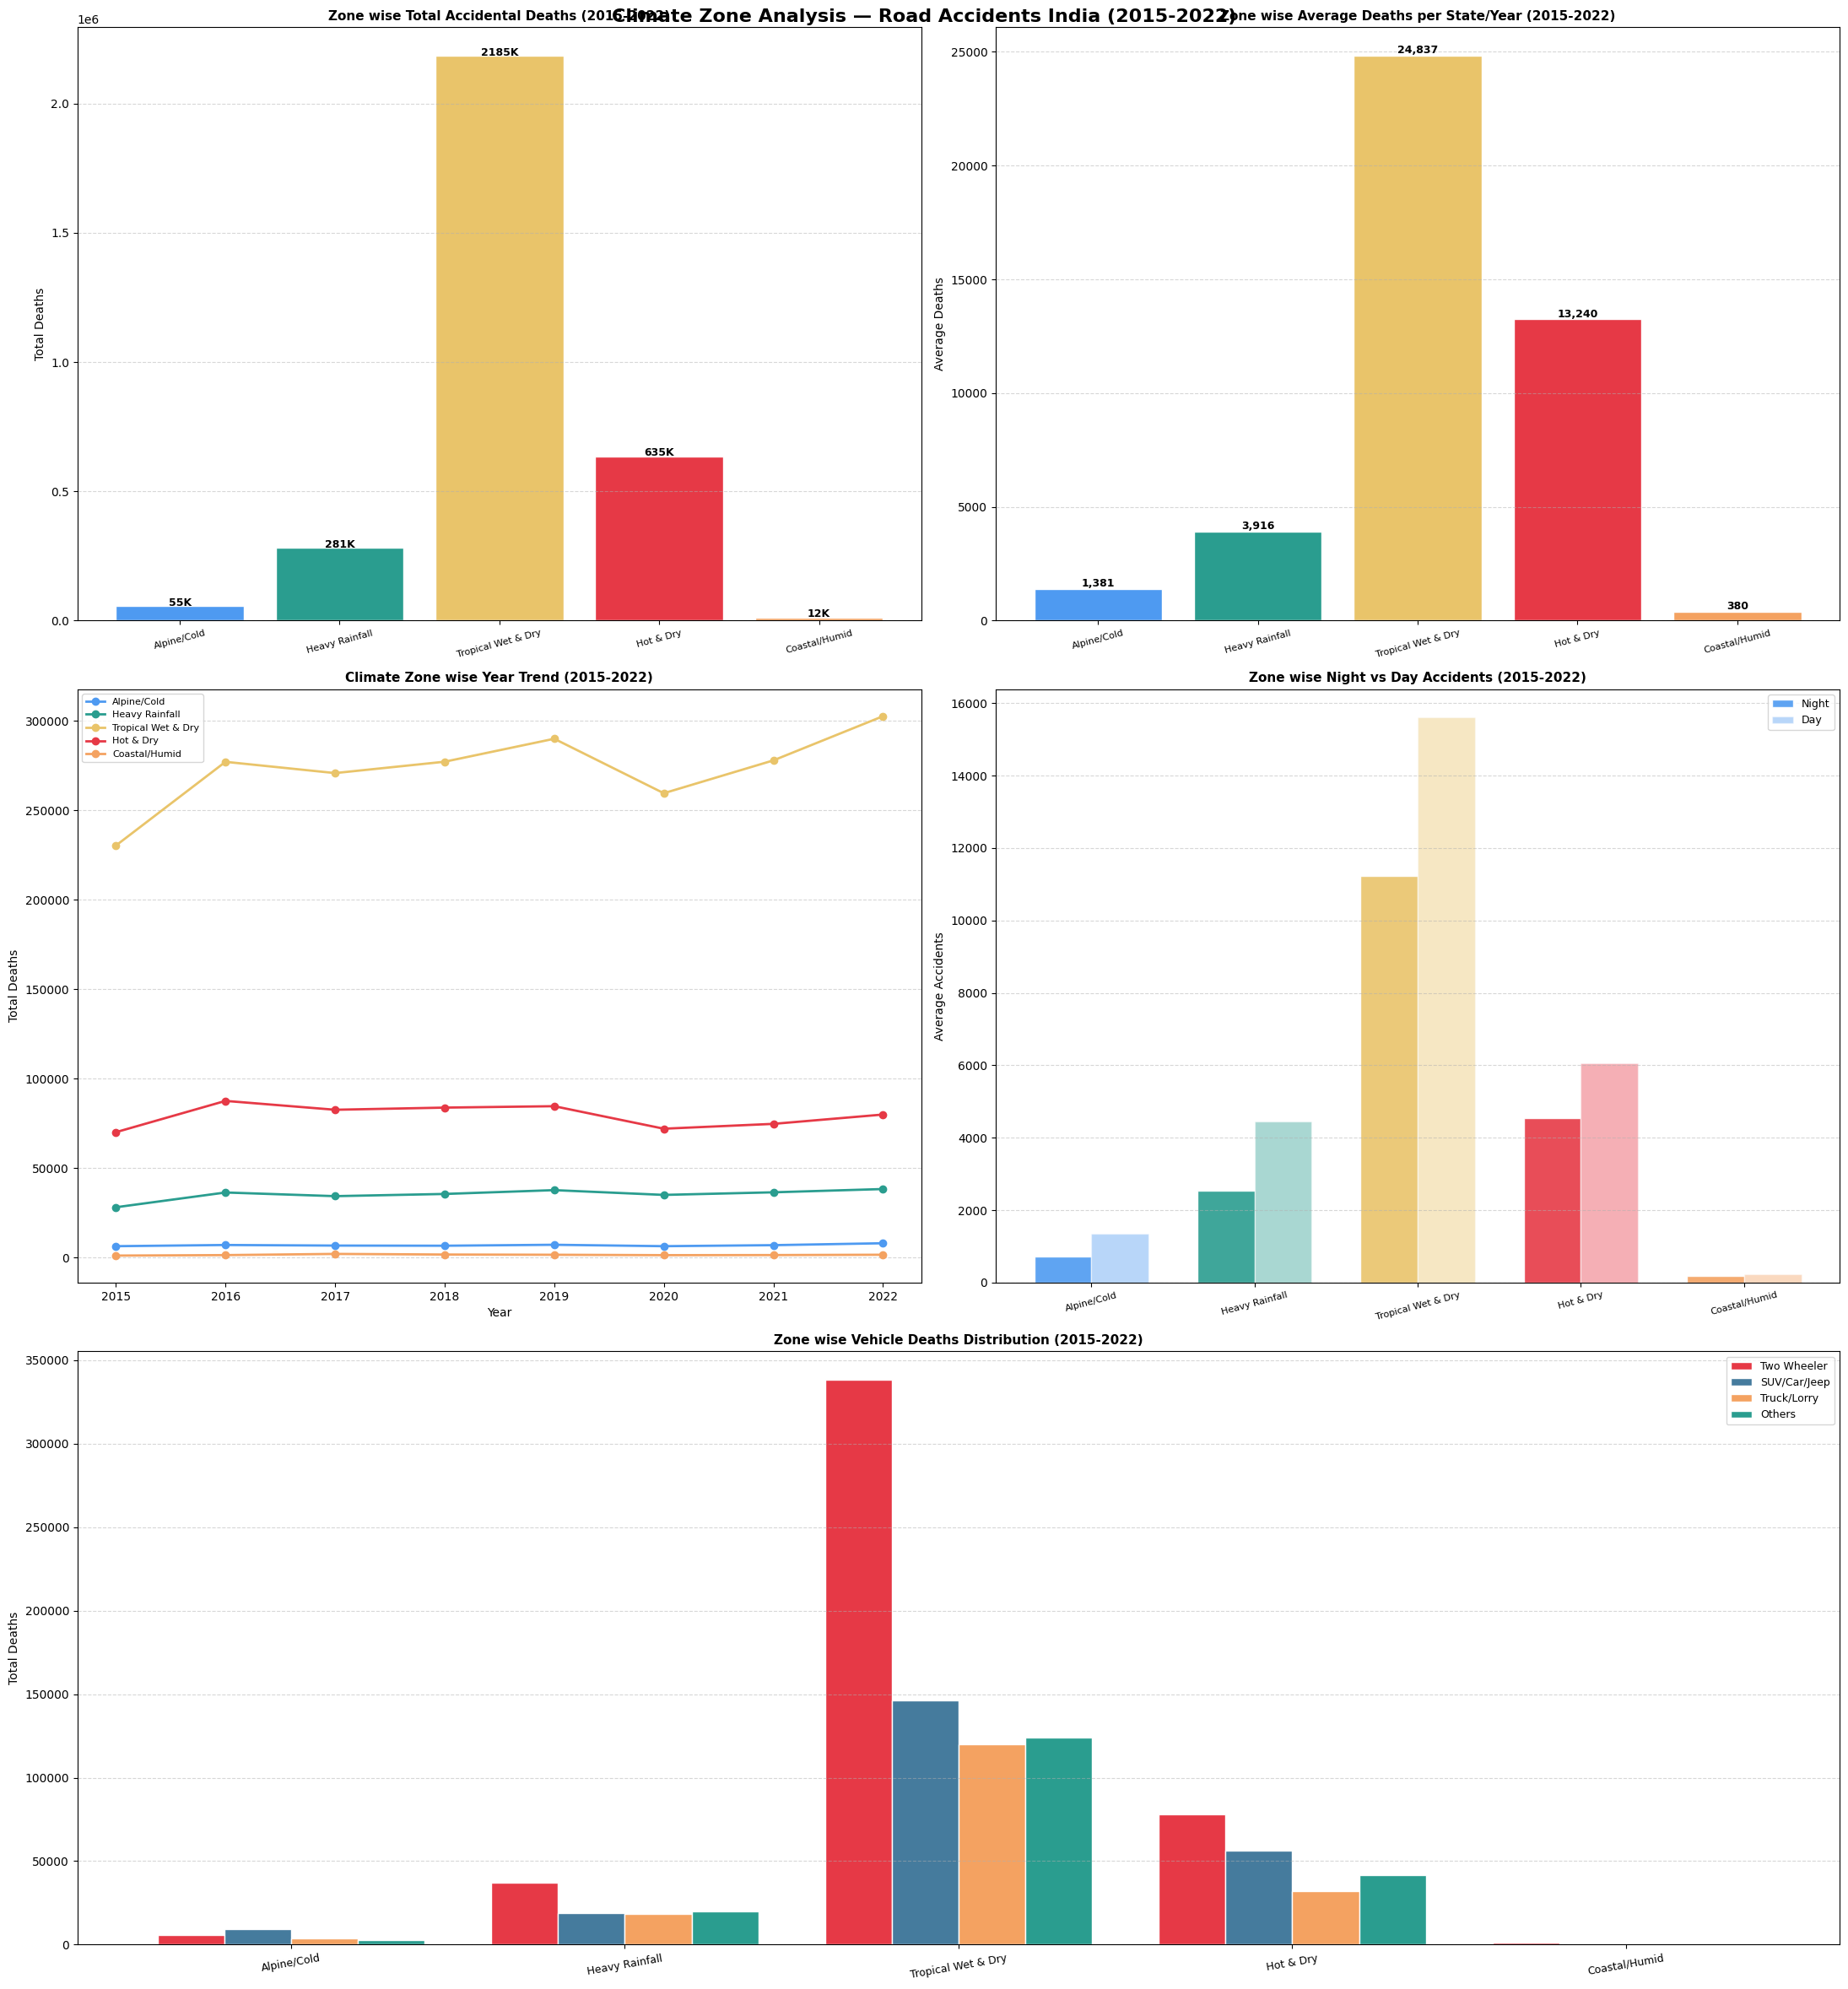


Zone wise Summary:
                    Total_Deaths  Avg_Deaths  Night_Pct
Climate Zone                                           
Alpine/Cold                55241      1381.0       38.8
Heavy Rainfall            281996      3916.6       39.0
Tropical Wet & Dry       2185682     24837.3       41.4
Hot & Dry                 635545     13240.5       45.5
Coastal/Humid              12176       380.5       41.5


In [13]:
# Analysis 6 - Climate Zone Analysis

# Define Climate Zones
climate_zones = {
    "Alpine/Cold": ["Himachal Pradesh", "Uttarakhand", "Jammu and Kashmir", 
                    "Arunachal Pradesh", "Sikkim"],
    "Heavy Rainfall": ["Kerala", "Assam", "Meghalaya", "Manipur", "Mizoram", 
                       "Nagaland", "Tripura", "West Bengal", "Goa"],
    "Tropical Wet & Dry": ["Andhra Pradesh", "Bihar", "Chhattisgarh", "Jharkhand", 
                            "Karnataka", "Madhya Pradesh", "Maharashtra", "Odisha", 
                            "Tamil Nadu", "Telangana", "Uttar Pradesh"],
    "Hot & Dry": ["Rajasthan", "Gujarat", "Haryana", "Punjab", "Delhi", "Chandigarh"],
    "Coastal/Humid": ["Andaman and Nicobar Islands", "Lakshadweep", "Puducherry", 
                      "Dadra and Nagar Haveli and Daman and Diu"]
}

# Add climate zone to master_df
zone_map = {}
for zone, states in climate_zones.items():
    for state in states:
        zone_map[state] = zone

master_df["Climate Zone"] = master_df["State/UT"].map(zone_map)

zone_order = ["Alpine/Cold", "Heavy Rainfall", "Tropical Wet & Dry", 
              "Hot & Dry", "Coastal/Humid"]
zone_colors = {
    "Alpine/Cold": "#4e9af1",
    "Heavy Rainfall": "#2a9d8f",
    "Tropical Wet & Dry": "#e9c46a",
    "Hot & Dry": "#e63946",
    "Coastal/Humid": "#f4a261"
}

# ============================================================
# CHART 1 - Zone wise Total Deaths
# ============================================================
zone_deaths = master_df.groupby("Climate Zone")["Total Accidental Deaths"].sum().reset_index()
zone_deaths = zone_deaths.set_index("Climate Zone").reindex(zone_order).reset_index()

# ============================================================
# CHART 2 - Zone wise Average Deaths per State
# ============================================================
zone_avg = master_df.groupby("Climate Zone")["Total Accidental Deaths"].mean().reset_index()
zone_avg = zone_avg.set_index("Climate Zone").reindex(zone_order).reset_index()

# ============================================================
# CHART 3 - Zone wise Year Trend
# ============================================================
zone_year = master_df.groupby(["Year", "Climate Zone"])["Total Accidental Deaths"].sum().reset_index()

# ============================================================
# CHART 4 - Zone wise Night vs Day
# ============================================================
night_cols = ["0000 hrs to 0300 hrs (Night)", "0300 hrs to 0600 hrs (Night)",
              "1800 hrs to 2100 hrs (Night)", "2100 hrs to 2400 hrs (Night)"]
day_cols = ["0600 hrs to 0900 hrs (Day)", "0900 hrs to 1200 hrs (Day)",
            "1200 hrs to 1500 hrs (Day)", "1500 hrs to 1800 hrs (Day)"]

master_df["Total Night"] = master_df[night_cols].sum(axis=1)
master_df["Total Day"] = master_df[day_cols].sum(axis=1)
master_df["Night %"] = (master_df["Total Night"] / 
                         (master_df["Total Night"] + master_df["Total Day"]) * 100)

zone_night = master_df.groupby("Climate Zone")[["Total Night", "Total Day", "Night %"]]\
             .mean().reset_index()
zone_night = zone_night.set_index("Climate Zone").reindex(zone_order).reset_index()

# ============================================================
# CHART 5 - Zone wise Vehicle Distribution
# ============================================================
vehicle_cols = ["Two Wheeler - Died", "SUV/Car/Jeep - Died", 
                "Truck/Lorry/Mini Truck - Died", "Other Motor Vehicles - Died"]
zone_vehicle = master_df.groupby("Climate Zone")[vehicle_cols].sum()
zone_vehicle = zone_vehicle.reindex(zone_order)

# ============================================================
# PLOT ALL
# ============================================================
fig = plt.figure(figsize=(22, 24))

# Chart 1 - Total Deaths
ax1 = fig.add_subplot(3, 2, 1)
bars = ax1.bar(zone_deaths["Climate Zone"], zone_deaths["Total Accidental Deaths"],
               color=[zone_colors[z] for z in zone_order], edgecolor="white")
for bar, val in zip(bars, zone_deaths["Total Accidental Deaths"]):
    ax1.text(bar.get_x() + bar.get_width()/2, val + 1000,
             f"{int(val/1000)}K", ha="center", fontsize=9, fontweight="bold")
ax1.set_title("Zone wise Total Accidental Deaths (2015-2022)",
              fontsize=11, fontweight="bold")
ax1.set_ylabel("Total Deaths", fontsize=10)
ax1.tick_params(axis='x', rotation=15, labelsize=8)
ax1.grid(axis="y", linestyle="--", alpha=0.5)

# Chart 2 - Average Deaths per State
ax2 = fig.add_subplot(3, 2, 2)
bars = ax2.bar(zone_avg["Climate Zone"], zone_avg["Total Accidental Deaths"],
               color=[zone_colors[z] for z in zone_order], edgecolor="white")
for bar, val in zip(bars, zone_avg["Total Accidental Deaths"]):
    ax2.text(bar.get_x() + bar.get_width()/2, val + 100,
             f"{int(val):,}", ha="center", fontsize=9, fontweight="bold")
ax2.set_title("Zone wise Average Deaths per State/Year (2015-2022)",
              fontsize=11, fontweight="bold")
ax2.set_ylabel("Average Deaths", fontsize=10)
ax2.tick_params(axis='x', rotation=15, labelsize=8)
ax2.grid(axis="y", linestyle="--", alpha=0.5)

# Chart 3 - Year Trend
ax3 = fig.add_subplot(3, 2, 3)
for zone in zone_order:
    data = zone_year[zone_year["Climate Zone"] == zone]
    ax3.plot(data["Year"], data["Total Accidental Deaths"],
             marker="o", linewidth=2, label=zone, color=zone_colors[zone])
ax3.set_title("Climate Zone wise Year Trend (2015-2022)",
              fontsize=11, fontweight="bold")
ax3.set_xlabel("Year", fontsize=10)
ax3.set_ylabel("Total Deaths", fontsize=10)
ax3.legend(fontsize=8)
ax3.set_xticks(range(2015, 2023))
ax3.grid(axis="y", linestyle="--", alpha=0.5)

# Chart 4 - Night % per Zone
ax4 = fig.add_subplot(3, 2, 4)
x = np.arange(len(zone_order))
width = 0.35
ax4.bar(x - width/2, zone_night["Total Night"],
        width=width, label="Night", 
        color=[zone_colors[z] for z in zone_order], edgecolor="white", alpha=0.9)
ax4.bar(x + width/2, zone_night["Total Day"],
        width=width, label="Day",
        color=[zone_colors[z] for z in zone_order], edgecolor="white", alpha=0.4)
ax4.set_xticks(x)
ax4.set_xticklabels(zone_order, rotation=15, fontsize=8)
ax4.set_title("Zone wise Night vs Day Accidents (2015-2022)",
              fontsize=11, fontweight="bold")
ax4.set_ylabel("Average Accidents", fontsize=10)
ax4.legend(fontsize=9)
ax4.grid(axis="y", linestyle="--", alpha=0.5)

# Chart 5 - Vehicle Distribution per Zone
ax5 = fig.add_subplot(3, 1, 3)
vehicle_labels = ["Two Wheeler", "SUV/Car/Jeep", "Truck/Lorry", "Others"]
x = np.arange(len(zone_order))
width = 0.2
colors_v = ["#e63946", "#457b9d", "#f4a261", "#2a9d8f"]
for i, (col, label) in enumerate(zip(vehicle_cols, vehicle_labels)):
    ax5.bar(x + i * width, zone_vehicle[col],
            width=width, label=label, color=colors_v[i], edgecolor="white")
ax5.set_xticks(x + width * 1.5)
ax5.set_xticklabels(zone_order, fontsize=9, rotation=10)
ax5.set_title("Zone wise Vehicle Deaths Distribution (2015-2022)",
              fontsize=11, fontweight="bold")
ax5.set_ylabel("Total Deaths", fontsize=10)
ax5.legend(fontsize=9)
ax5.grid(axis="y", linestyle="--", alpha=0.5)

plt.suptitle("Climate Zone Analysis — Road Accidents India (2015-2022)",
             fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

# Print key stats
print("\nZone wise Summary:")
summary = master_df.groupby("Climate Zone").agg(
    Total_Deaths=("Total Accidental Deaths", "sum"),
    Avg_Deaths=("Total Accidental Deaths", "mean"),
    Night_Pct=("Night %", "mean")
).reindex(zone_order).round(1)
print(summary.to_string())

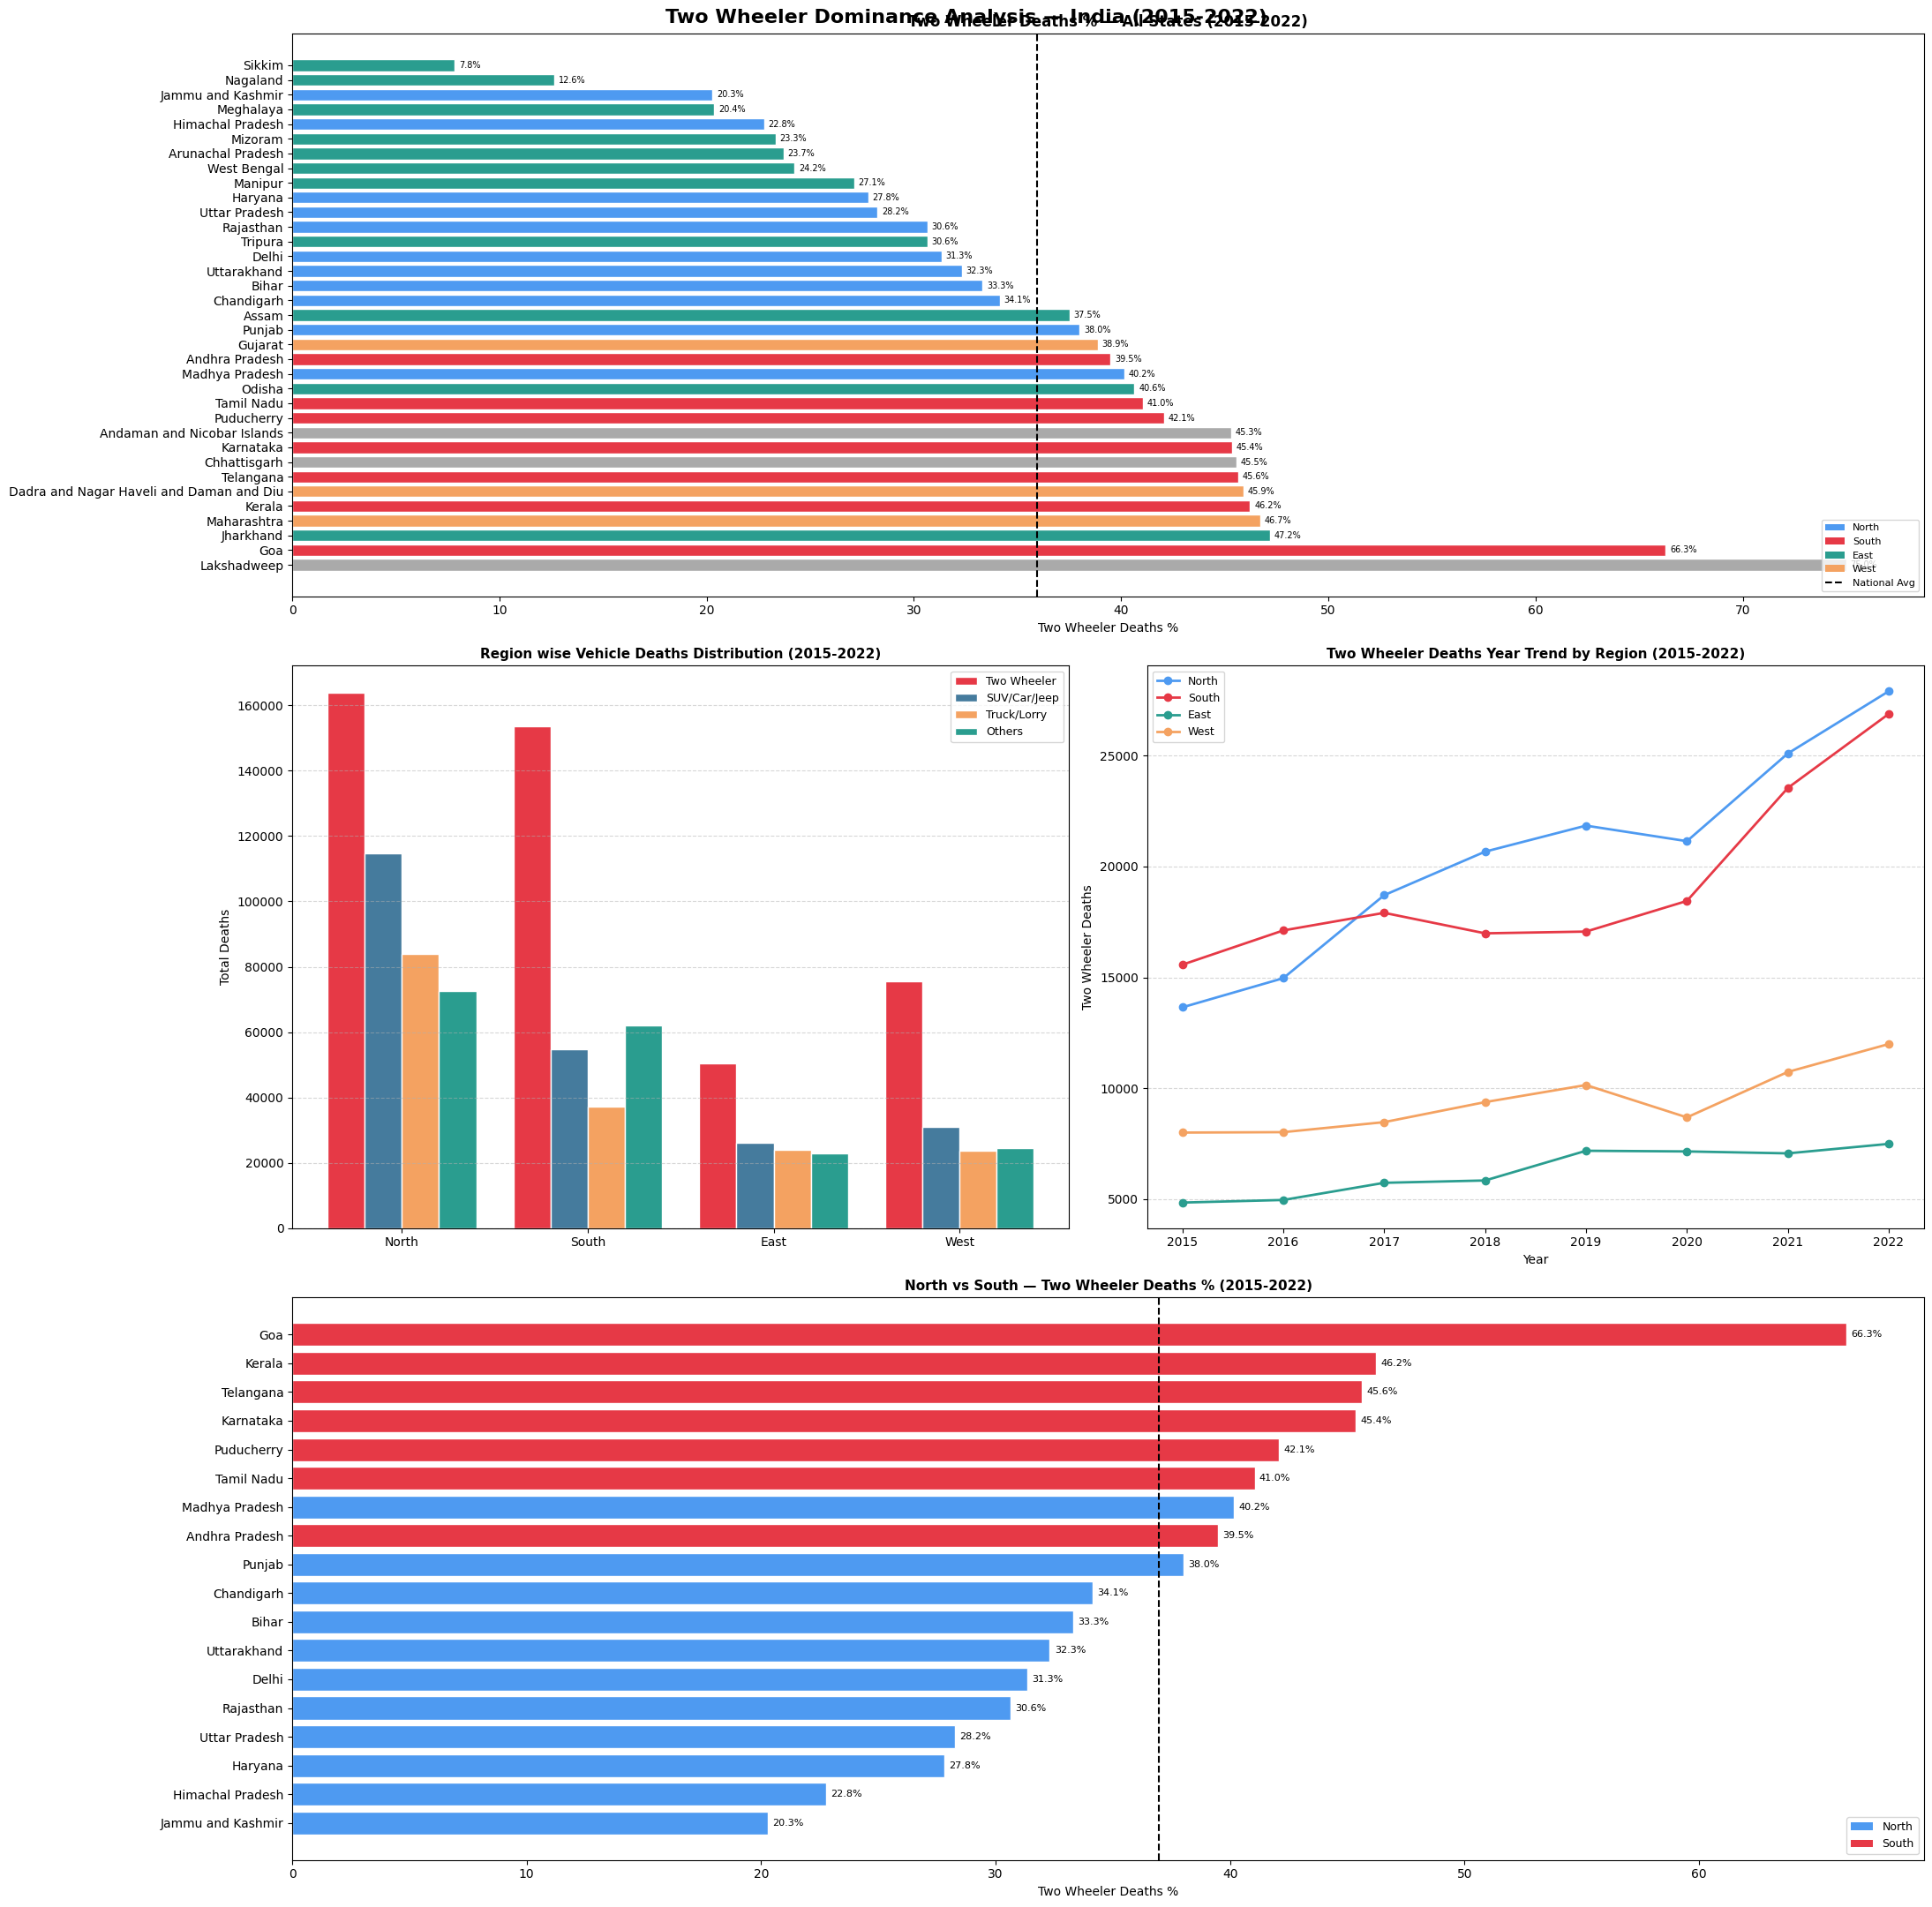


Region wise Two Wheeler Summary:
        Two Wheeler - Died
Region                    
North               163953
South               153503
East                 50300
West                 75448

North avg Two Wheeler %: 30.8%
South avg Two Wheeler %: 46.6%


In [14]:
# Analysis 7 - Two Wheeler Dominance — North vs South India

# Define North vs South states
north_states = ["Uttar Pradesh", "Punjab", "Haryana", "Delhi", "Rajasthan",
                "Madhya Pradesh", "Bihar", "Uttarakhand", "Himachal Pradesh",
                "Jammu and Kashmir", "Chandigarh"]

south_states = ["Tamil Nadu", "Karnataka", "Kerala", "Andhra Pradesh", 
                "Telangana", "Goa", "Puducherry"]

east_states = ["West Bengal", "Odisha", "Jharkhand", "Assam", "Bihar",
               "Arunachal Pradesh", "Meghalaya", "Manipur", "Mizoram",
               "Nagaland", "Tripura", "Sikkim"]

west_states = ["Maharashtra", "Gujarat", "Rajasthan",
               "Dadra and Nagar Haveli and Daman and Diu"]

# Add region to master_df
def get_region(state):
    if state in north_states:
        return "North"
    elif state in south_states:
        return "South"
    elif state in east_states:
        return "East"
    elif state in west_states:
        return "West"
    else:
        return "Other"

master_df["Region"] = master_df["State/UT"].map(get_region)

region_order = ["North", "South", "East", "West"]
region_colors = {"North": "#4e9af1", "South": "#e63946", 
                 "East": "#2a9d8f", "West": "#f4a261", "Other": "#aaa"}

# ============================================================
# CHART 1 - Two Wheeler Deaths % per State
# ============================================================
state_transport = transport_df.copy()
state_transport["Total Vehicle Deaths"] = state_transport[
    ["Truck/Lorry/Mini Truck - Died", "Bus - Died", "SUV/Car/Jeep - Died",
     "Tractor - Died", "Three Wheeler/Auto Rickshaw - Died",
     "Two Wheeler - Died", "Other Motor Vehicles - Died"]].sum(axis=1)
state_transport["Two Wheeler %"] = (
    state_transport["Two Wheeler - Died"] / 
    state_transport["Total Vehicle Deaths"] * 100
).round(1)

state_2w = state_transport.groupby("State/UT").agg(
    Two_Wheeler_Deaths=("Two Wheeler - Died", "sum"),
    Total_Vehicle_Deaths=("Total Vehicle Deaths", "sum"),
    Two_Wheeler_Pct=("Two Wheeler %", "mean")
).reset_index().sort_values("Two_Wheeler_Pct", ascending=False)

# Add region
state_2w["Region"] = state_2w["State/UT"].map(get_region)

# ============================================================
# CHART 2 - Region wise Two Wheeler vs Other Vehicles
# ============================================================
region_2w = master_df.groupby("Region")[
    ["Two Wheeler - Died", "SUV/Car/Jeep - Died", 
     "Truck/Lorry/Mini Truck - Died", "Other Motor Vehicles - Died"]].sum()
region_2w = region_2w.reindex(region_order)

# ============================================================
# CHART 3 - Two Wheeler Deaths Year Trend by Region
# ============================================================
region_year_2w = master_df.groupby(["Year", "Region"])["Two Wheeler - Died"].sum().reset_index()

# ============================================================
# CHART 4 - North vs South Two Wheeler % Comparison
# ============================================================
ns_df = state_2w[state_2w["Region"].isin(["North", "South"])]

# ============================================================
# PLOT ALL
# ============================================================
fig = plt.figure(figsize=(22, 22))

# Chart 1 - Two Wheeler % per State
ax1 = fig.add_subplot(3, 2, (1, 2))
colors_bar = [region_colors.get(r, "#aaa") for r in state_2w["Region"]]
bars = ax1.barh(state_2w["State/UT"], state_2w["Two_Wheeler_Pct"],
                color=colors_bar, edgecolor="white")
for bar, val in zip(bars, state_2w["Two_Wheeler_Pct"]):
    ax1.text(val + 0.2, bar.get_y() + bar.get_height()/2,
             f"{val:.1f}%", va="center", fontsize=7)
ax1.axvline(x=state_2w["Two_Wheeler_Pct"].mean(), color="black",
            linewidth=1.5, linestyle="--", 
            label=f"National Avg: {state_2w['Two_Wheeler_Pct'].mean():.1f}%")
ax1.set_title("Two Wheeler Deaths % — All States (2015-2022)",
              fontsize=12, fontweight="bold")
ax1.set_xlabel("Two Wheeler Deaths %", fontsize=10)
ax1.legend(fontsize=9)

# Region legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=region_colors[r], label=r) for r in region_order]
ax1.legend(handles=legend_elements + [
    plt.Line2D([0], [0], color="black", linewidth=1.5, 
               linestyle="--", label=f"National Avg")
], fontsize=8, loc="lower right")

# Chart 2 - Region wise Vehicle Distribution
ax2 = fig.add_subplot(3, 2, 3)
vehicle_labels = ["Two Wheeler", "SUV/Car/Jeep", "Truck/Lorry", "Others"]
x = np.arange(len(region_order))
width = 0.2
colors_v = ["#e63946", "#457b9d", "#f4a261", "#2a9d8f"]
for i, (col, label) in enumerate(zip(
    ["Two Wheeler - Died", "SUV/Car/Jeep - Died", 
     "Truck/Lorry/Mini Truck - Died", "Other Motor Vehicles - Died"],
    vehicle_labels
)):
    ax2.bar(x + i * width, region_2w[col],
            width=width, label=label, color=colors_v[i], edgecolor="white")
ax2.set_xticks(x + width * 1.5)
ax2.set_xticklabels(region_order, fontsize=10)
ax2.set_title("Region wise Vehicle Deaths Distribution (2015-2022)",
              fontsize=11, fontweight="bold")
ax2.set_ylabel("Total Deaths", fontsize=10)
ax2.legend(fontsize=9)
ax2.grid(axis="y", linestyle="--", alpha=0.5)

# Chart 3 - Year Trend by Region
ax3 = fig.add_subplot(3, 2, 4)
for region in region_order:
    data = region_year_2w[region_year_2w["Region"] == region]
    ax3.plot(data["Year"], data["Two Wheeler - Died"],
             marker="o", linewidth=2, label=region, 
             color=region_colors[region])
ax3.set_title("Two Wheeler Deaths Year Trend by Region (2015-2022)",
              fontsize=11, fontweight="bold")
ax3.set_xlabel("Year", fontsize=10)
ax3.set_ylabel("Two Wheeler Deaths", fontsize=10)
ax3.legend(fontsize=9)
ax3.set_xticks(range(2015, 2023))
ax3.grid(axis="y", linestyle="--", alpha=0.5)

# Chart 4 - North vs South Comparison
ax4 = fig.add_subplot(3, 2, (5, 6))
ns_sorted = ns_df.sort_values("Two_Wheeler_Pct", ascending=True)
colors_ns = [region_colors[r] for r in ns_sorted["Region"]]
bars = ax4.barh(ns_sorted["State/UT"], ns_sorted["Two_Wheeler_Pct"],
                color=colors_ns, edgecolor="white")
for bar, val in zip(bars, ns_sorted["Two_Wheeler_Pct"]):
    ax4.text(val + 0.2, bar.get_y() + bar.get_height()/2,
             f"{val:.1f}%", va="center", fontsize=8)
ax4.axvline(x=ns_df["Two_Wheeler_Pct"].mean(), color="black",
            linewidth=1.5, linestyle="--")
ax4.set_title("North vs South — Two Wheeler Deaths % (2015-2022)",
              fontsize=11, fontweight="bold")
ax4.set_xlabel("Two Wheeler Deaths %", fontsize=10)

legend_ns = [Patch(facecolor=region_colors["North"], label="North"),
             Patch(facecolor=region_colors["South"], label="South")]
ax4.legend(handles=legend_ns, fontsize=9)

plt.suptitle("Two Wheeler Dominance Analysis — India (2015-2022)",
             fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

# Print stats
print("\nRegion wise Two Wheeler Summary:")
print(region_2w[["Two Wheeler - Died"]].to_string())
print(f"\nNorth avg Two Wheeler %: {ns_df[ns_df['Region']=='North']['Two_Wheeler_Pct'].mean():.1f}%")
print(f"South avg Two Wheeler %: {ns_df[ns_df['Region']=='South']['Two_Wheeler_Pct'].mean():.1f}%")

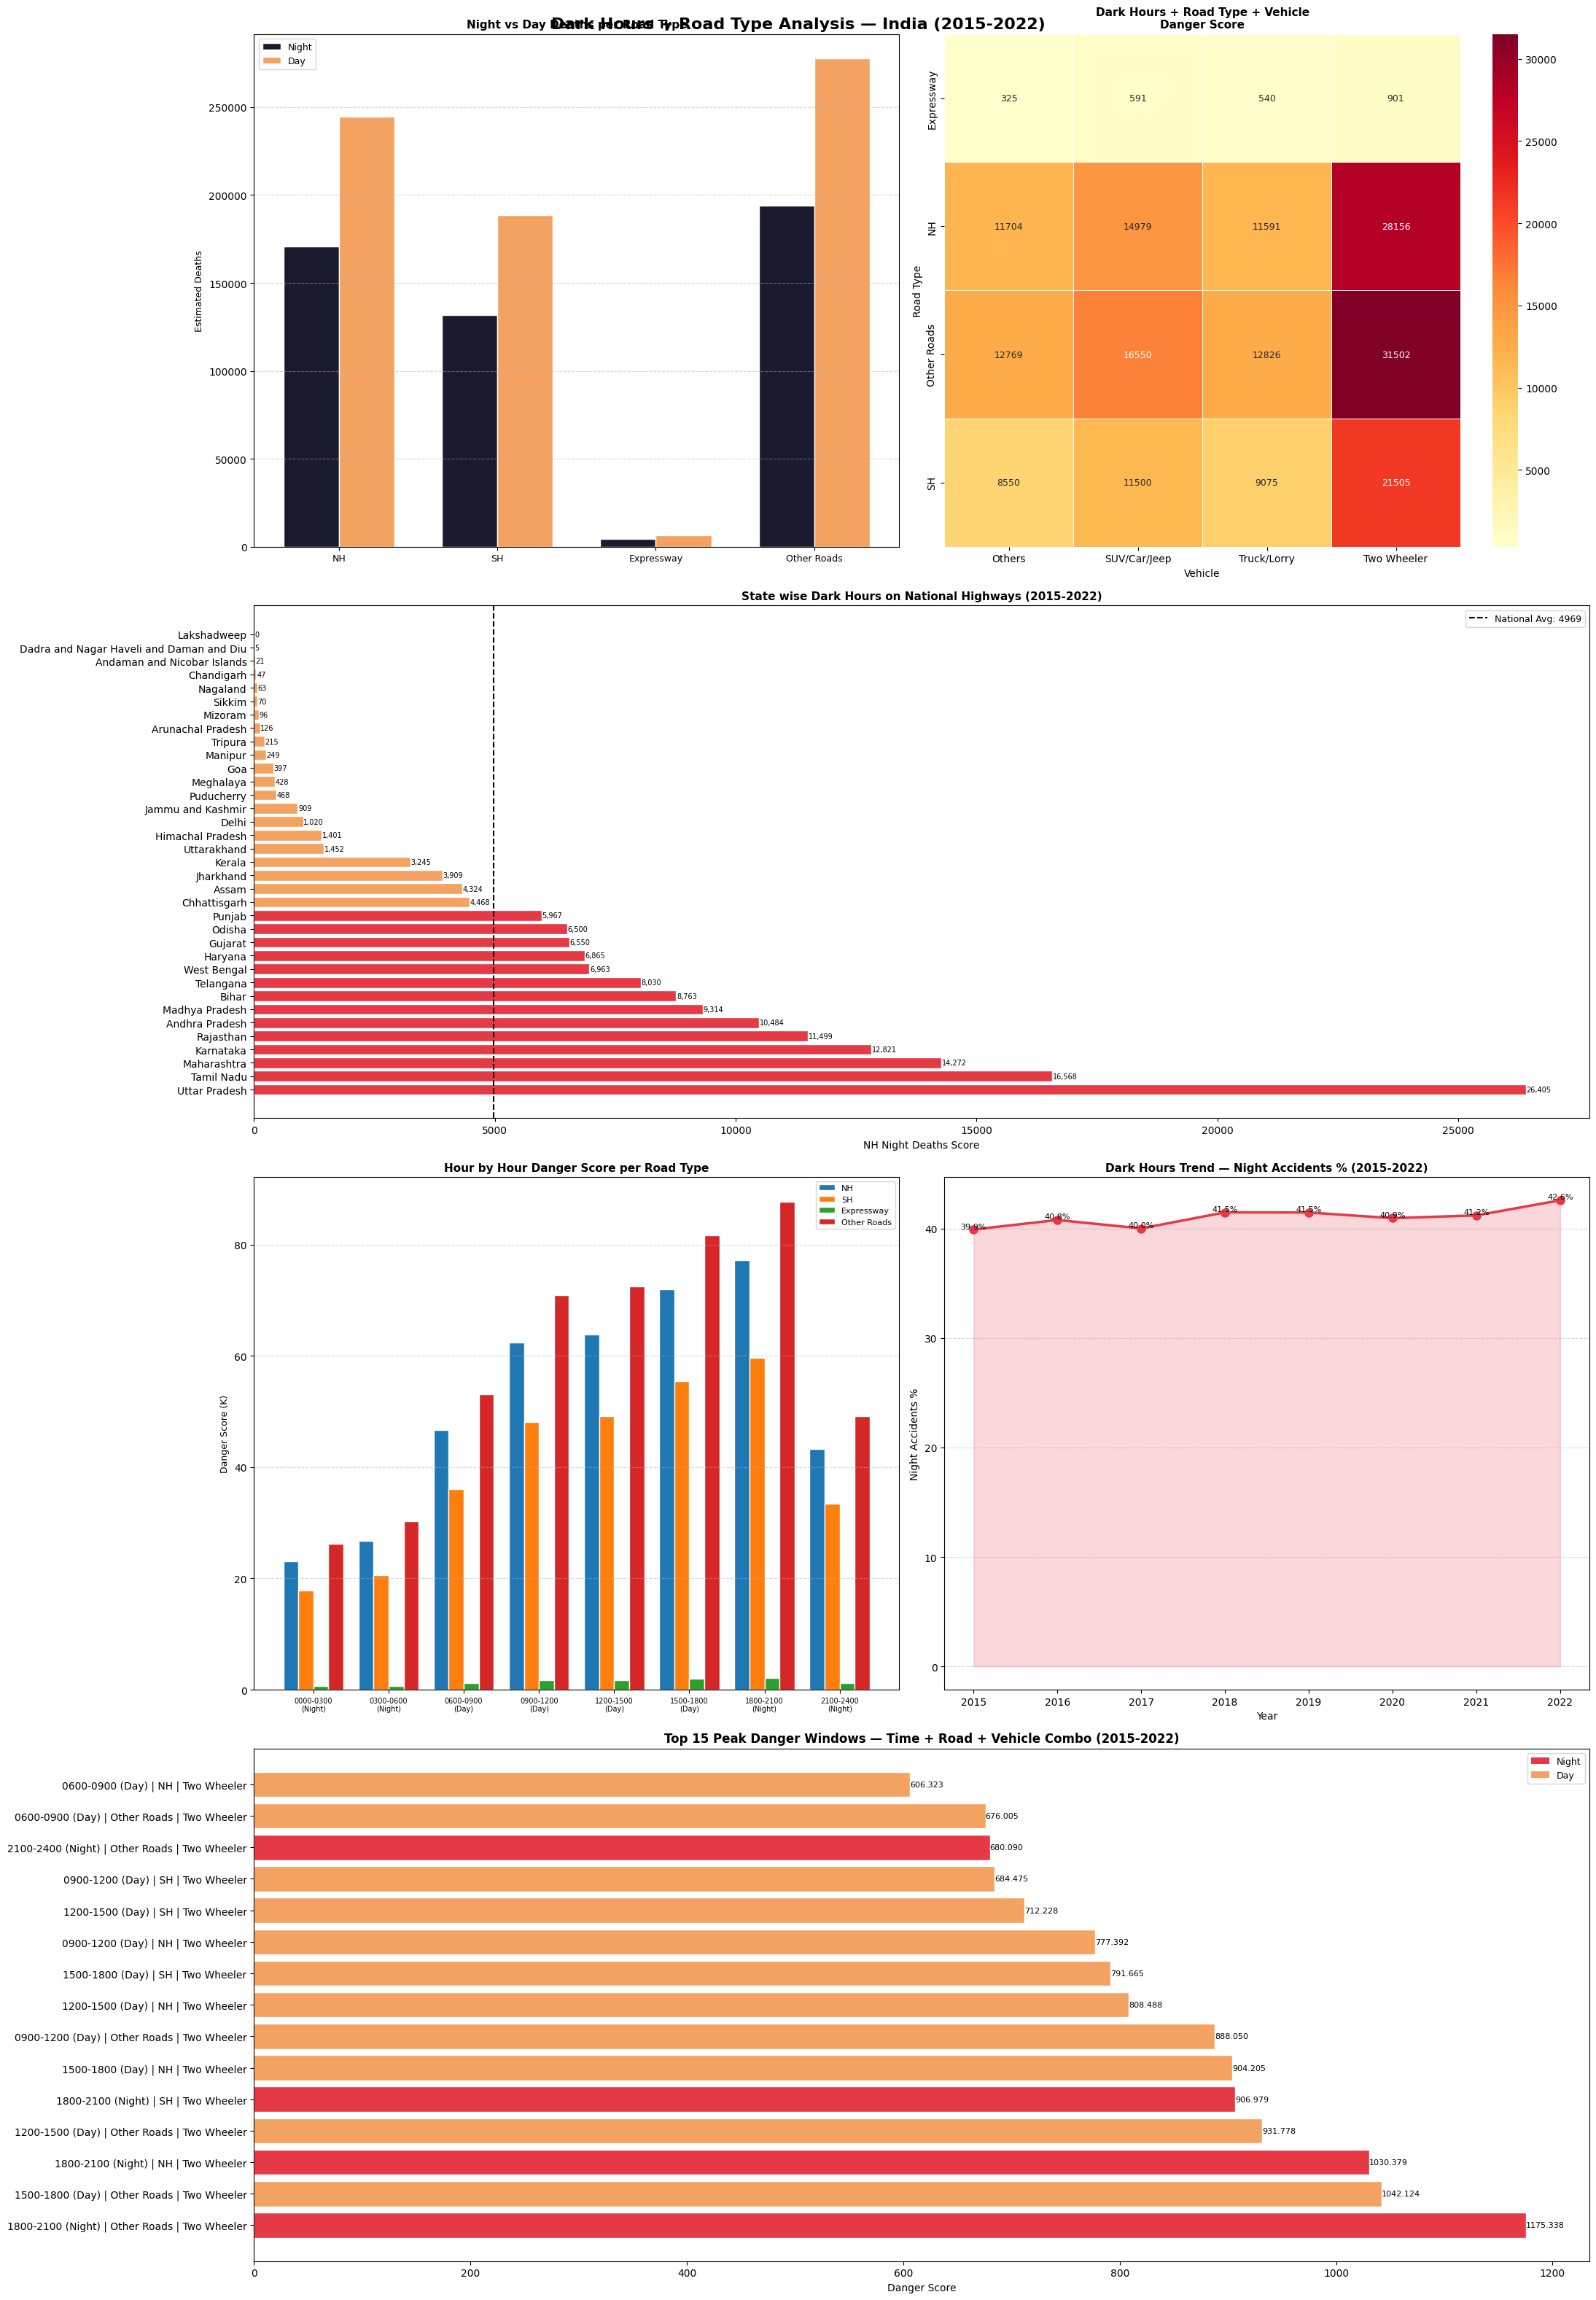


Top 15 Peak Danger Windows:
                                  Combination  Danger Score
1800-2100 (Night) | Other Roads | Two Wheeler   1175.337557
  1500-1800 (Day) | Other Roads | Two Wheeler   1042.124011
         1800-2100 (Night) | NH | Two Wheeler   1030.379458
  1200-1500 (Day) | Other Roads | Two Wheeler    931.777694
         1800-2100 (Night) | SH | Two Wheeler    906.979300
           1500-1800 (Day) | NH | Two Wheeler    904.204695
  0900-1200 (Day) | Other Roads | Two Wheeler    888.050338
           1200-1500 (Day) | NH | Two Wheeler    808.487512
           1500-1800 (Day) | SH | Two Wheeler    791.665106
           0900-1200 (Day) | NH | Two Wheeler    777.391845
           1200-1500 (Day) | SH | Two Wheeler    712.228358
           0900-1200 (Day) | SH | Two Wheeler    684.475327
2100-2400 (Night) | Other Roads | Two Wheeler    680.090252
  0600-0900 (Day) | Other Roads | Two Wheeler    676.005375
           0600-0900 (Day) | NH | Two Wheeler    606.323452


In [15]:
# Analysis 8 - Dark Hours + Road Type Combo - Complete Analysis

# ============================================================
# Setup - Merge time and road data
# ============================================================
time_road_df = master_df.copy()

night_slots = ["0000 hrs to 0300 hrs (Night)", "0300 hrs to 0600 hrs (Night)",
               "1800 hrs to 2100 hrs (Night)", "2100 hrs to 2400 hrs (Night)"]
day_slots = ["0600 hrs to 0900 hrs (Day)", "0900 hrs to 1200 hrs (Day)",
             "1200 hrs to 1500 hrs (Day)", "1500 hrs to 1800 hrs (Day)"]

road_types = ["National Highways - Died", "State Highways - Died",
              "Expressways - Died", "Other Roads - Died"]
road_labels = ["NH", "SH", "Expressway", "Other Roads"]

vehicle_types = ["Two Wheeler - Died", "SUV/Car/Jeep - Died",
                 "Truck/Lorry/Mini Truck - Died", "Other Motor Vehicles - Died"]
vehicle_labels = ["Two Wheeler", "SUV/Car/Jeep", "Truck/Lorry", "Others"]

time_road_df["Total Night"] = time_road_df[night_slots].sum(axis=1)
time_road_df["Total Day"] = time_road_df[day_slots].sum(axis=1)
time_road_df["Total Accidents"] = time_road_df["Total Night"] + time_road_df["Total Day"]
time_road_df["Night %"] = (time_road_df["Total Night"] / 
                            time_road_df["Total Accidents"] * 100).round(1)

fig = plt.figure(figsize=(22, 32))

# ============================================================
# CHART 1 - Night vs Day per Road Type
# ============================================================
ax1 = fig.add_subplot(4, 2, 1)

road_night = pd.DataFrame({
    "Road Type": road_labels,
    "Night Deaths": [time_road_df[r].sum() * time_road_df["Night %"].mean() / 100 
                     for r in road_types],
    "Day Deaths": [time_road_df[r].sum() * (100 - time_road_df["Night %"].mean()) / 100 
                   for r in road_types]
})

x = np.arange(len(road_labels))
width = 0.35
ax1.bar(x - width/2, road_night["Night Deaths"], width=width,
        label="Night", color="#1a1a2e", edgecolor="white")
ax1.bar(x + width/2, road_night["Day Deaths"], width=width,
        label="Day", color="#f4a261", edgecolor="white")
ax1.set_xticks(x)
ax1.set_xticklabels(road_labels, fontsize=9)
ax1.set_title("Night vs Day Deaths per Road Type",
              fontsize=11, fontweight="bold")
ax1.set_ylabel("Estimated Deaths", fontsize=9)
ax1.legend(fontsize=9)
ax1.grid(axis="y", linestyle="--", alpha=0.5)

# ============================================================
# CHART 2 - Dark Hours + Road Type + Vehicle Heatmap
# ============================================================
ax2 = fig.add_subplot(4, 2, 2)

combo_data = []
for road, road_label in zip(road_types, road_labels):
    for vehicle, vehicle_label in zip(vehicle_types, vehicle_labels):
        score = (time_road_df[road] * time_road_df["Night %"] / 100 * 
                 time_road_df[vehicle] / time_road_df["Total Accidents"]).sum()
        combo_data.append({
            "Road Type": road_label,
            "Vehicle": vehicle_label,
            "Danger Score": score
        })

combo_df = pd.DataFrame(combo_data)
combo_pivot = combo_df.pivot(index="Road Type", columns="Vehicle", values="Danger Score")

sns.heatmap(combo_pivot, annot=True, fmt=".0f", cmap="YlOrRd",
            ax=ax2, linewidths=0.5, annot_kws={"size": 9})
ax2.set_title("Dark Hours + Road Type + Vehicle\nDanger Score",
              fontsize=11, fontweight="bold")

# ============================================================
# CHART 3 - State wise Dark Hours on NH
# ============================================================
ax3 = fig.add_subplot(4, 2, (3, 4))

state_nh_night = time_road_df.groupby("State/UT").agg(
    NH_Deaths=("National Highways - Died", "sum"),
    Night_Pct=("Night %", "mean")
).reset_index()
state_nh_night["NH Night Score"] = (state_nh_night["NH_Deaths"] * 
                                     state_nh_night["Night_Pct"] / 100).round(0)
state_nh_night = state_nh_night.sort_values("NH Night Score", ascending=False)

colors_nh = ["#e63946" if x > state_nh_night["NH Night Score"].mean() 
             else "#f4a261" for x in state_nh_night["NH Night Score"]]
bars = ax3.barh(state_nh_night["State/UT"], state_nh_night["NH Night Score"],
                color=colors_nh, edgecolor="white")
for bar, val in zip(bars, state_nh_night["NH Night Score"]):
    ax3.text(val + 10, bar.get_y() + bar.get_height()/2,
             f"{int(val):,}", va="center", fontsize=7)
ax3.axvline(x=state_nh_night["NH Night Score"].mean(), 
            color="black", linewidth=1.5, linestyle="--",
            label=f"National Avg: {state_nh_night['NH Night Score'].mean():.0f}")
ax3.set_title("State wise Dark Hours on National Highways (2015-2022)",
              fontsize=11, fontweight="bold")
ax3.set_xlabel("NH Night Deaths Score", fontsize=10)
ax3.legend(fontsize=9)

# ============================================================
# CHART 4 - Hour by Hour Danger Score per Road Type
# ============================================================
ax4 = fig.add_subplot(4, 2, 5)

all_slots = night_slots[:2] + day_slots + night_slots[2:]
slot_labels = ["0000-0300\n(Night)", "0300-0600\n(Night)",
               "0600-0900\n(Day)", "0900-1200\n(Day)",
               "1200-1500\n(Day)", "1500-1800\n(Day)",
               "1800-2100\n(Night)", "2100-2400\n(Night)"]
slot_colors = ["#1a1a2e", "#16213e", "#f4a261", "#e9c46a",
               "#e9c46a", "#f4a261", "#e63946", "#1a1a2e"]

x = np.arange(len(all_slots))
width = 0.2
for i, (road, label) in enumerate(zip(road_types, road_labels)):
    road_total = time_road_df[road].sum()
    scores = [time_road_df[slot].sum() * road_total / 
              time_road_df["Total Accidents"].sum() / 1000
              for slot in all_slots]
    ax4.bar(x + i * width, scores, width=width, label=label, edgecolor="white")

ax4.set_xticks(x + width * 1.5)
ax4.set_xticklabels(slot_labels, fontsize=7)
ax4.set_title("Hour by Hour Danger Score per Road Type",
              fontsize=11, fontweight="bold")
ax4.set_ylabel("Danger Score (K)", fontsize=9)
ax4.legend(fontsize=8)
ax4.grid(axis="y", linestyle="--", alpha=0.5)

# ============================================================
# CHART 5 - Dark Hours Trend 2015-2022
# ============================================================
ax5 = fig.add_subplot(4, 2, 6)

yearly_night = time_road_df.groupby("Year")[night_slots + day_slots].sum()
yearly_night["Total Night"] = yearly_night[night_slots].sum(axis=1)
yearly_night["Total Day"] = yearly_night[day_slots].sum(axis=1)
yearly_night["Night %"] = (yearly_night["Total Night"] / 
                            (yearly_night["Total Night"] + yearly_night["Total Day"]) * 100)

ax5.plot(yearly_night.index, yearly_night["Night %"],
         marker="o", linewidth=2.5, color="#e63946", markersize=8)
for year, val in zip(yearly_night.index, yearly_night["Night %"]):
    ax5.text(year, val + 0.1, f"{val:.1f}%", ha="center", fontsize=8)
ax5.set_title("Dark Hours Trend — Night Accidents % (2015-2022)",
              fontsize=11, fontweight="bold")
ax5.set_xlabel("Year", fontsize=10)
ax5.set_ylabel("Night Accidents %", fontsize=10)
ax5.set_xticks(range(2015, 2023))
ax5.grid(axis="y", linestyle="--", alpha=0.5)
ax5.fill_between(yearly_night.index, yearly_night["Night %"],
                 alpha=0.2, color="#e63946")

# ============================================================
# CHART 6 - Peak Danger Window
# ============================================================
ax6 = fig.add_subplot(4, 1, 4)

# Calculate danger score for each time slot + road + vehicle combo
peak_data = []
for slot, slot_label in zip(all_slots, slot_labels):
    for road, road_label in zip(road_types, road_labels):
        for vehicle, vehicle_label in zip(vehicle_types, vehicle_labels):
            score = (time_road_df[slot] * time_road_df[road] * 
                     time_road_df[vehicle]).sum() / 1e10
            peak_data.append({
                "Combination": f"{slot_label.replace(chr(10), ' ')} | {road_label} | {vehicle_label}",
                "Danger Score": score,
                "Time": slot_label.replace('\n', ' '),
                "Road": road_label,
                "Vehicle": vehicle_label
            })

peak_df = pd.DataFrame(peak_data).sort_values("Danger Score", ascending=False).head(15)

colors_peak = ["#e63946" if "Night" in c else "#f4a261" 
               for c in peak_df["Time"]]
bars = ax6.barh(peak_df["Combination"], peak_df["Danger Score"],
                color=colors_peak, edgecolor="white")
for bar, val in zip(bars, peak_df["Danger Score"]):
    ax6.text(val + 0.001, bar.get_y() + bar.get_height()/2,
             f"{val:.3f}", va="center", fontsize=8)
ax6.set_title("Top 15 Peak Danger Windows — Time + Road + Vehicle Combo (2015-2022)",
              fontsize=12, fontweight="bold")
ax6.set_xlabel("Danger Score", fontsize=10)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor="#e63946", label="Night"),
                   Patch(facecolor="#f4a261", label="Day")]
ax6.legend(handles=legend_elements, fontsize=9)

plt.suptitle("Dark Hours + Road Type Analysis — India (2015-2022)",
             fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

# Print Peak Danger Window
print("\nTop 15 Peak Danger Windows:")
print(peak_df[["Combination", "Danger Score"]].to_string(index=False))

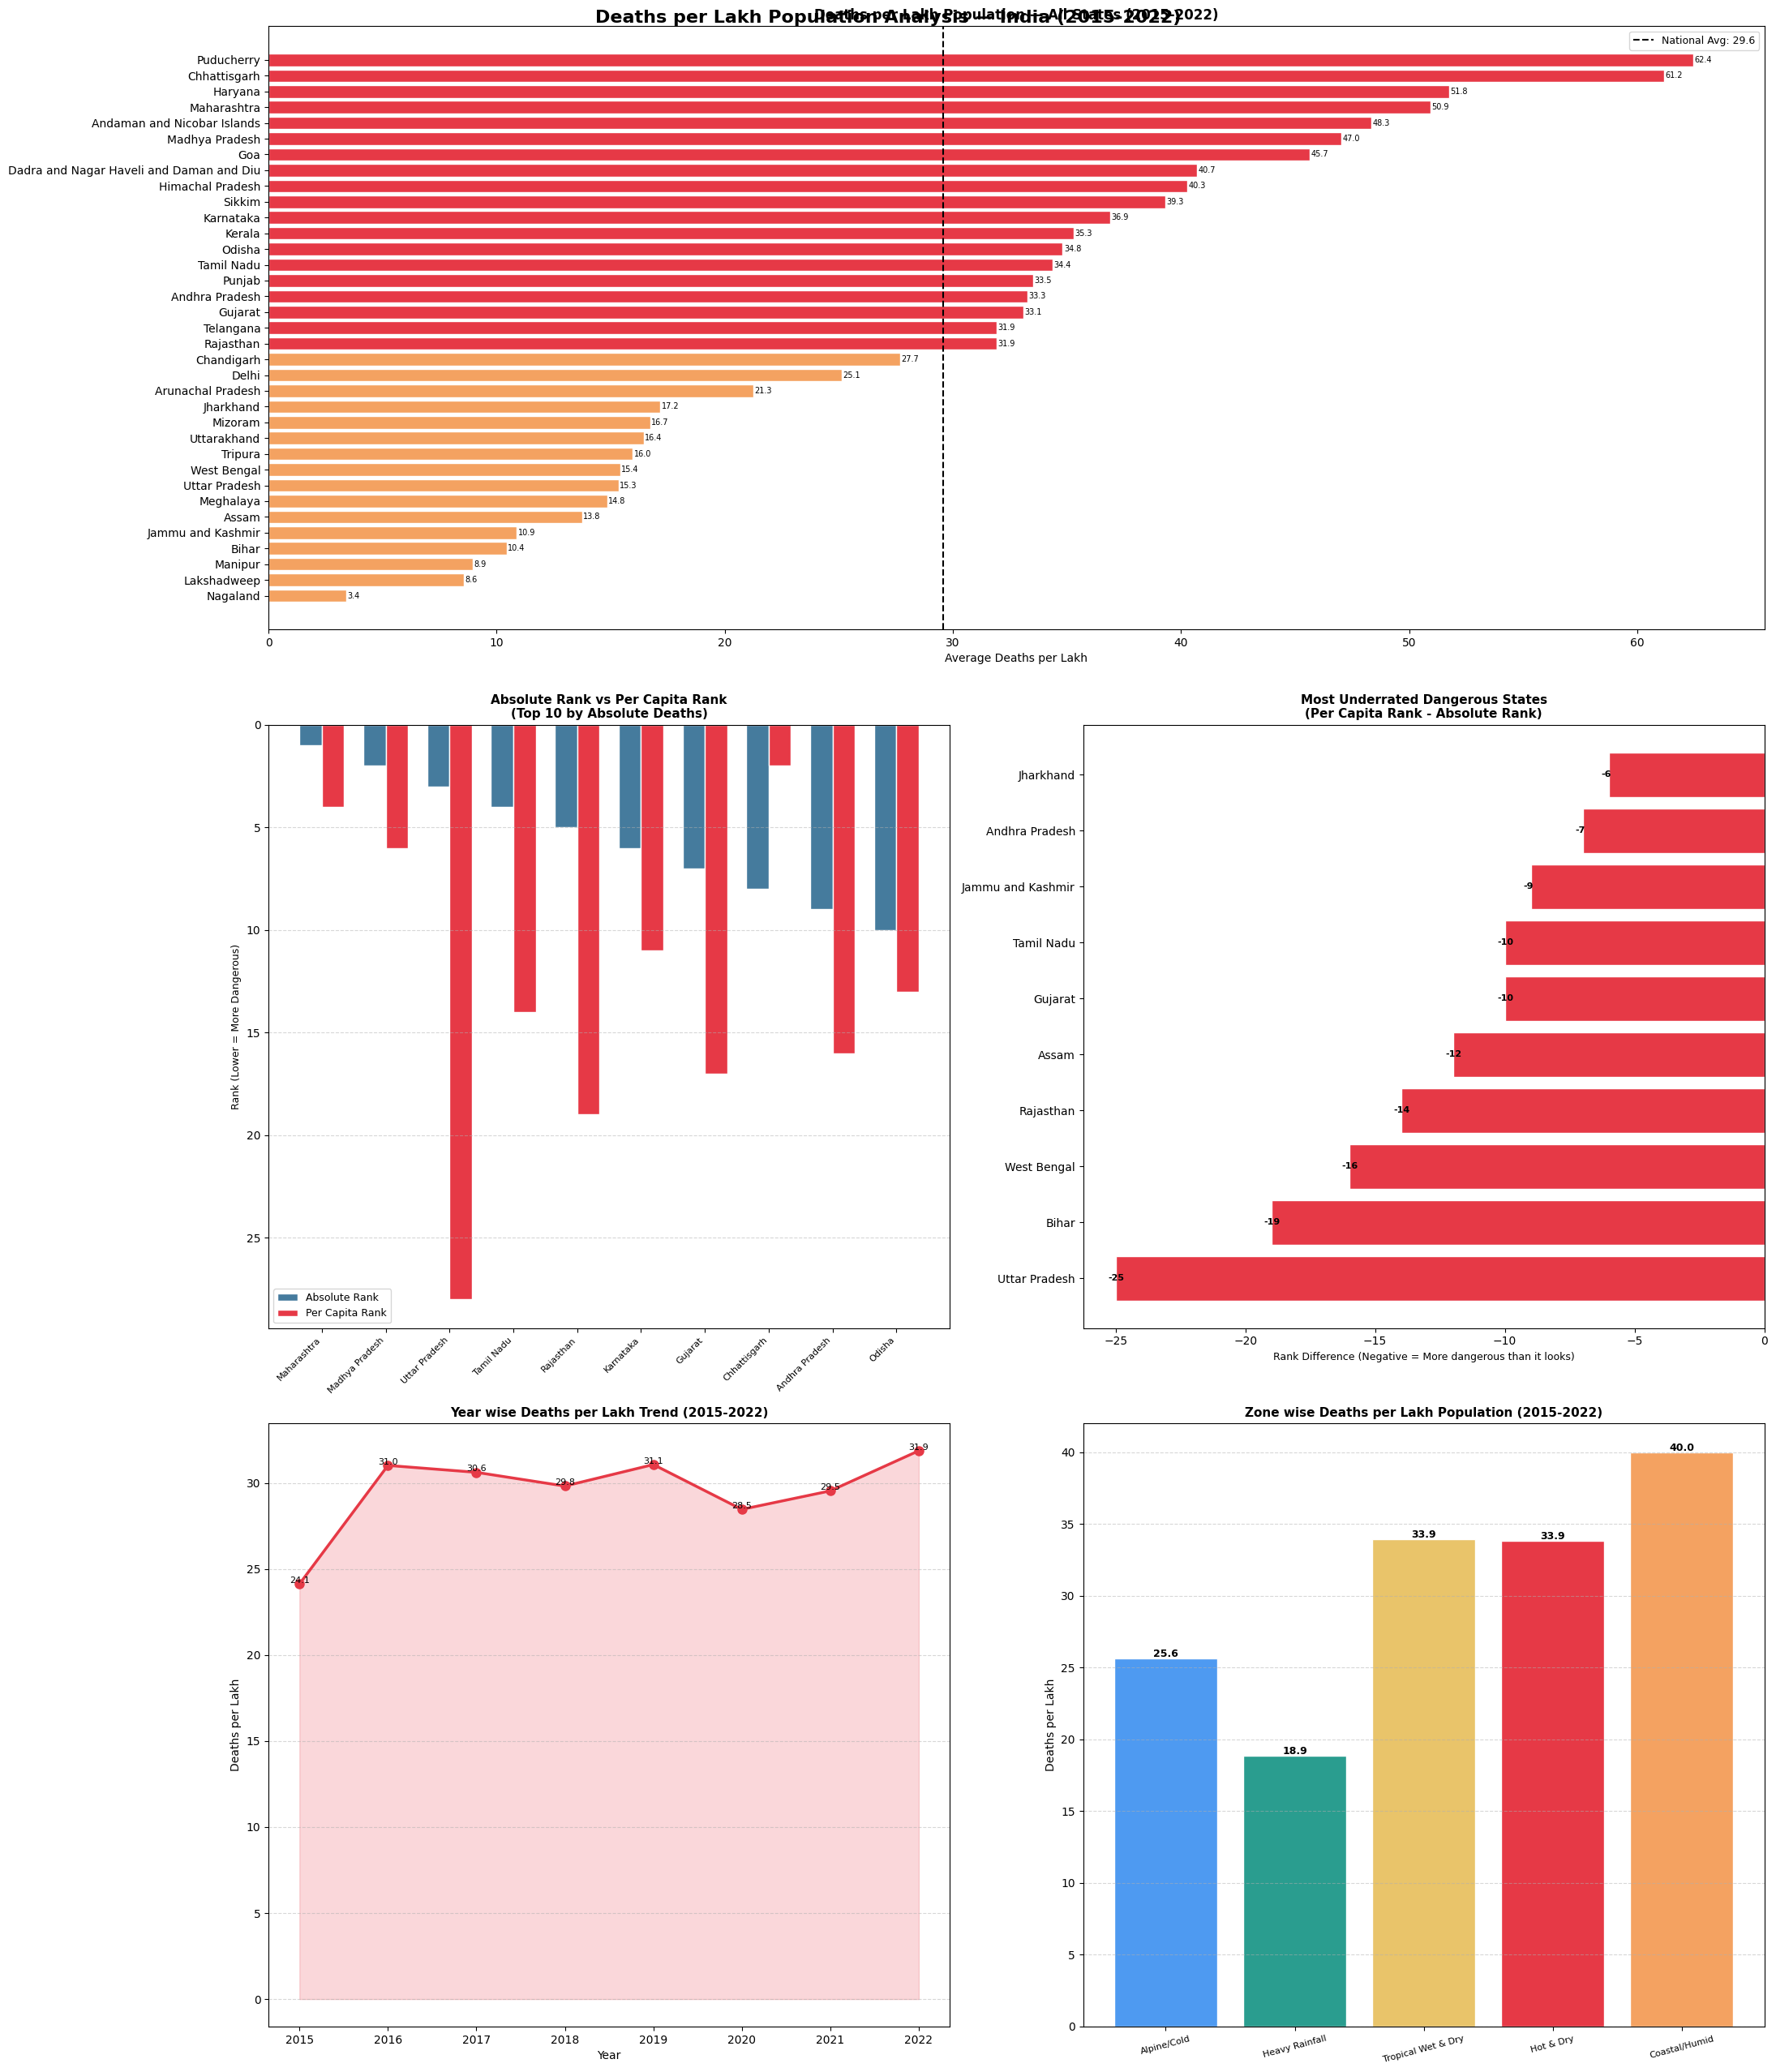


Top 10 Most Dangerous States (Per Capita):
                                State/UT  Avg_Deaths  Avg_Deaths_per_Lakh
                              Puducherry    1044.750             62.44750
                            Chhattisgarh   17888.125             61.18375
                                 Haryana   14676.250             51.75500
                             Maharashtra   63272.000             50.93500
             Andaman and Nicobar Islands     191.875             48.33125
                          Madhya Pradesh   40137.250             47.02375
                                     Goa     724.125             45.65625
Dadra and Nagar Haveli and Daman and Diu     279.125             40.68750
                        Himachal Pradesh    2953.250             40.28500
                                  Sikkim     271.750             39.32625

Top 10 Underrated States:
         State/UT  Absolute Rank  PerCapita Rank  Rank Difference
    Uttar Pradesh              3              28 

In [16]:
# Analysis 9 - Deaths per Lakh Population

# State wise population data (2021 Census estimates in Lakhs)
population_data = {
    "Andaman and Nicobar Islands": 3.97,
    "Andhra Pradesh": 495.63,
    "Arunachal Pradesh": 15.84,
    "Assam": 351.07,
    "Bihar": 1239.26,
    "Chandigarh": 11.58,
    "Chhattisgarh": 292.36,
    "Dadra and Nagar Haveli and Daman and Diu": 6.86,
    "Delhi": 190.14,
    "Goa": 15.86,
    "Gujarat": 709.04,
    "Haryana": 283.57,
    "Himachal Pradesh": 73.31,
    "Jammu and Kashmir": 133.06,
    "Jharkhand": 382.93,
    "Karnataka": 673.62,
    "Kerala": 354.99,
    "Lakshadweep": 0.73,
    "Madhya Pradesh": 853.58,
    "Maharashtra": 1242.21,
    "Manipur": 32.37,
    "Meghalaya": 32.11,
    "Mizoram": 12.39,
    "Nagaland": 21.89,
    "Odisha": 463.56,
    "Puducherry": 16.73,
    "Punjab": 303.57,
    "Rajasthan": 815.03,
    "Sikkim": 6.91,
    "Tamil Nadu": 772.34,
    "Telangana": 384.67,
    "Tripura": 40.99,
    "Uttar Pradesh": 2352.88,
    "Uttarakhand": 115.18,
    "West Bengal": 1004.07
}

# Add population to deaths_df
deaths_df["Population (Lakhs)"] = deaths_df["State/UT"].map(population_data)
deaths_df["Deaths per Lakh"] = (
    deaths_df["Total Accidental Deaths"] / 
    deaths_df["Population (Lakhs)"]
).round(2)

# Average deaths per lakh per state
state_percapita = deaths_df.groupby("State/UT").agg(
    Avg_Deaths=("Total Accidental Deaths", "mean"),
    Avg_Deaths_per_Lakh=("Deaths per Lakh", "mean"),
    Population=("Population (Lakhs)", "mean")
).reset_index().sort_values("Avg_Deaths_per_Lakh", ascending=False)

# Absolute ranking
state_absolute = deaths_df.groupby("State/UT")["Total Accidental Deaths"]\
                 .mean().reset_index().sort_values("Total Accidental Deaths", ascending=False)
state_absolute["Absolute Rank"] = range(1, len(state_absolute) + 1)

# Per capita ranking
state_percapita["PerCapita Rank"] = range(1, len(state_percapita) + 1)

# Merge for comparison
ranking_df = state_absolute.merge(
    state_percapita[["State/UT", "PerCapita Rank", "Avg_Deaths_per_Lakh"]],
    on="State/UT"
)
ranking_df["Rank Difference"] = ranking_df["Absolute Rank"] - ranking_df["PerCapita Rank"]

# Year wise per capita
yearly_percapita = deaths_df.groupby("Year")["Deaths per Lakh"].mean().reset_index()

# Zone wise per capita
master_df["Population (Lakhs)"] = master_df["State/UT"].map(population_data)
master_df["Deaths per Lakh"] = (
    master_df["Total Accidental Deaths"] / 
    master_df["Population (Lakhs)"]
).round(2)

zone_percapita = master_df.groupby("Climate Zone")["Deaths per Lakh"].mean()\
                 .reindex(zone_order).reset_index()

# ============================================================
# PLOT
# ============================================================
fig = plt.figure(figsize=(22, 26))

# Chart 1 - Deaths per Lakh - All States
ax1 = fig.add_subplot(3, 2, (1, 2))
state_sorted = state_percapita.sort_values("Avg_Deaths_per_Lakh", ascending=True)
colors_pc = ["#e63946" if x > state_percapita["Avg_Deaths_per_Lakh"].mean() 
             else "#f4a261" for x in state_sorted["Avg_Deaths_per_Lakh"]]
bars = ax1.barh(state_sorted["State/UT"], state_sorted["Avg_Deaths_per_Lakh"],
                color=colors_pc, edgecolor="white")
for bar, val in zip(bars, state_sorted["Avg_Deaths_per_Lakh"]):
    ax1.text(val + 0.05, bar.get_y() + bar.get_height()/2,
             f"{val:.1f}", va="center", fontsize=7)
ax1.axvline(x=state_percapita["Avg_Deaths_per_Lakh"].mean(),
            color="black", linewidth=1.5, linestyle="--",
            label=f"National Avg: {state_percapita['Avg_Deaths_per_Lakh'].mean():.1f}")
ax1.set_title("Deaths per Lakh Population — All States (2015-2022)",
              fontsize=12, fontweight="bold")
ax1.set_xlabel("Average Deaths per Lakh", fontsize=10)
ax1.legend(fontsize=9)

# Chart 2 - Absolute vs Per Capita Top 10
ax2 = fig.add_subplot(3, 2, 3)
top10_absolute = ranking_df.nsmallest(10, "Absolute Rank")[["State/UT", "Absolute Rank", "PerCapita Rank"]]
x = np.arange(len(top10_absolute))
width = 0.35
ax2.bar(x - width/2, top10_absolute["Absolute Rank"],
        width=width, label="Absolute Rank", color="#457b9d", edgecolor="white")
ax2.bar(x + width/2, top10_absolute["PerCapita Rank"],
        width=width, label="Per Capita Rank", color="#e63946", edgecolor="white")
ax2.set_xticks(x)
ax2.set_xticklabels(top10_absolute["State/UT"], rotation=45, fontsize=8, ha="right")
ax2.set_title("Absolute Rank vs Per Capita Rank\n(Top 10 by Absolute Deaths)",
              fontsize=11, fontweight="bold")
ax2.set_ylabel("Rank (Lower = More Dangerous)", fontsize=9)
ax2.legend(fontsize=9)
ax2.grid(axis="y", linestyle="--", alpha=0.5)
ax2.invert_yaxis()

# Chart 3 - Most Underrated Dangerous States
ax3 = fig.add_subplot(3, 2, 4)
underrated = ranking_df.sort_values("Rank Difference", ascending=True).head(10)
colors_under = ["#e63946" if x < 0 else "#2a9d8f" for x in underrated["Rank Difference"]]
bars = ax3.barh(underrated["State/UT"], underrated["Rank Difference"],
                color=colors_under, edgecolor="white")
for bar, val in zip(bars, underrated["Rank Difference"]):
    ax3.text(val - 0.3 if val < 0 else val + 0.1,
             bar.get_y() + bar.get_height()/2,
             f"{int(val)}", va="center", fontsize=8, fontweight="bold")
ax3.axvline(x=0, color="black", linewidth=0.8)
ax3.set_title("Most Underrated Dangerous States\n(Per Capita Rank - Absolute Rank)",
              fontsize=11, fontweight="bold")
ax3.set_xlabel("Rank Difference (Negative = More dangerous than it looks)",
               fontsize=9)

# Chart 4 - Year wise Per Capita Trend
ax4 = fig.add_subplot(3, 2, 5)
ax4.plot(yearly_percapita["Year"], yearly_percapita["Deaths per Lakh"],
         marker="o", linewidth=2.5, color="#e63946", markersize=8)
for year, val in zip(yearly_percapita["Year"], yearly_percapita["Deaths per Lakh"]):
    ax4.text(year, val + 0.05, f"{val:.1f}", ha="center", fontsize=8)
ax4.fill_between(yearly_percapita["Year"], yearly_percapita["Deaths per Lakh"],
                 alpha=0.2, color="#e63946")
ax4.set_title("Year wise Deaths per Lakh Trend (2015-2022)",
              fontsize=11, fontweight="bold")
ax4.set_xlabel("Year", fontsize=10)
ax4.set_ylabel("Deaths per Lakh", fontsize=10)
ax4.set_xticks(range(2015, 2023))
ax4.grid(axis="y", linestyle="--", alpha=0.5)

# Chart 5 - Zone wise Per Capita
ax5 = fig.add_subplot(3, 2, 6)
bars = ax5.bar(zone_percapita["Climate Zone"], zone_percapita["Deaths per Lakh"],
               color=[zone_colors[z] for z in zone_order], edgecolor="white")
for bar, val in zip(bars, zone_percapita["Deaths per Lakh"]):
    ax5.text(bar.get_x() + bar.get_width()/2, val + 0.1,
             f"{val:.1f}", ha="center", fontsize=9, fontweight="bold")
ax5.set_title("Zone wise Deaths per Lakh Population (2015-2022)",
              fontsize=11, fontweight="bold")
ax5.set_ylabel("Deaths per Lakh", fontsize=10)
ax5.tick_params(axis='x', rotation=15, labelsize=8)
ax5.grid(axis="y", linestyle="--", alpha=0.5)

plt.suptitle("Deaths per Lakh Population Analysis — India (2015-2022)",
             fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

# Print key findings
print("\nTop 10 Most Dangerous States (Per Capita):")
print(state_percapita.head(10)[["State/UT", "Avg_Deaths", 
      "Avg_Deaths_per_Lakh"]].to_string(index=False))

print("\nTop 10 Underrated States:")
print(ranking_df.sort_values("Rank Difference").head(10)[
    ["State/UT", "Absolute Rank", "PerCapita Rank", "Rank Difference"]
].to_string(index=False))

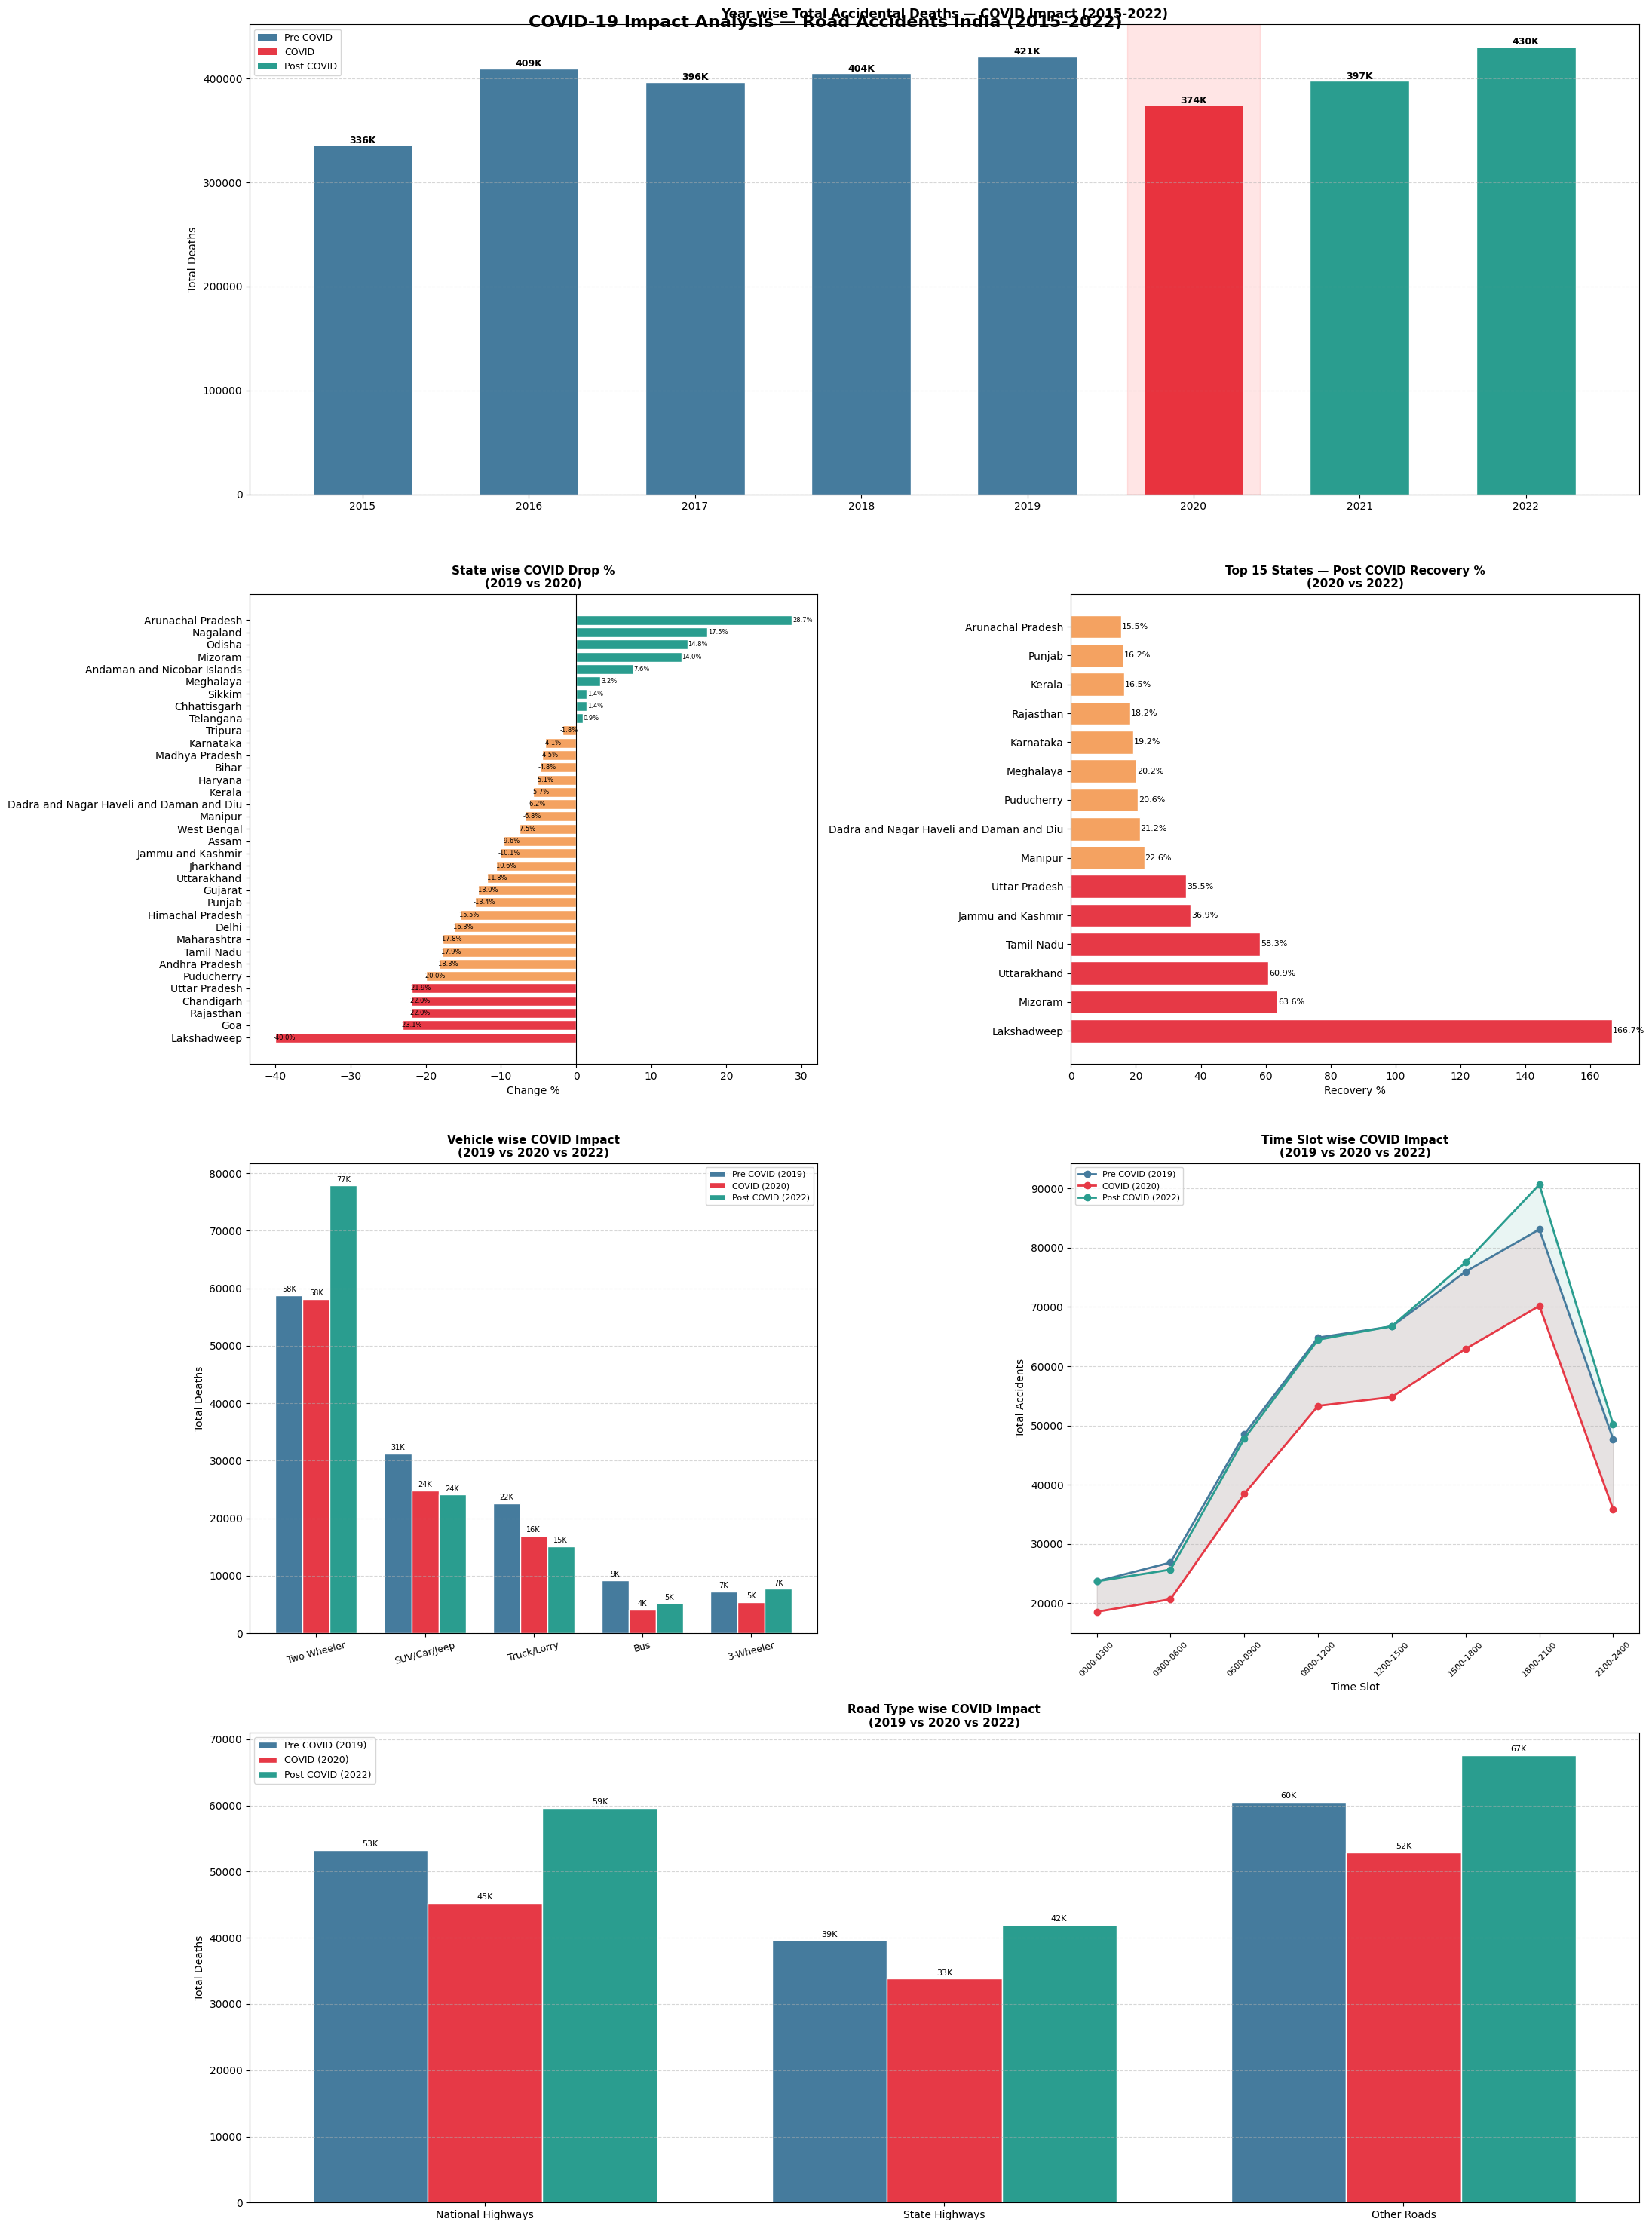


Overall COVID Impact:
2019 (Pre COVID): 421,104
2020 (COVID): 374,397 — Drop: -11.1%
2022 (Post COVID): 430,504 — Recovery: 15.0%

Top 5 COVID Drop States:
     State/UT  COVID Drop %
  Lakshadweep         -40.0
          Goa         -23.1
   Chandigarh         -22.0
    Rajasthan         -22.0
Uttar Pradesh         -21.9

Top 5 Recovery States:
         State/UT  Recovery %
      Lakshadweep       166.7
          Mizoram        63.6
      Uttarakhand        60.9
       Tamil Nadu        58.3
Jammu and Kashmir        36.9


In [18]:
# Analysis 10 - COVID Impact Analysis - COMPLETE

# ============================================================
# Setup
# ============================================================
period_order = ["Pre COVID", "COVID", "Post COVID"]
period_colors = {"Pre COVID": "#457b9d", "COVID": "#e63946", "Post COVID": "#2a9d8f"}

yearly_deaths = deaths_df.groupby("Year")["Total Accidental Deaths"].sum().reset_index()
yearly_deaths["Period"] = yearly_deaths["Year"].apply(
    lambda x: "Pre COVID" if x <= 2019 else "COVID" if x == 2020 else "Post COVID"
)

pre_covid = deaths_df[deaths_df["Year"] == 2019].set_index("State/UT")["Total Accidental Deaths"]
covid = deaths_df[deaths_df["Year"] == 2020].set_index("State/UT")["Total Accidental Deaths"]
post_covid = deaths_df[deaths_df["Year"] == 2022].set_index("State/UT")["Total Accidental Deaths"]

covid_impact = pd.DataFrame({
    "Pre COVID (2019)": pre_covid,
    "COVID (2020)": covid,
    "Post COVID (2022)": post_covid
}).dropna()

covid_impact["COVID Drop %"] = ((covid_impact["COVID (2020)"] -
                                  covid_impact["Pre COVID (2019)"]) /
                                  covid_impact["Pre COVID (2019)"] * 100).round(1)
covid_impact["Recovery %"] = ((covid_impact["Post COVID (2022)"] -
                                covid_impact["COVID (2020)"]) /
                                covid_impact["COVID (2020)"] * 100).round(1)
covid_impact = covid_impact.reset_index()

vehicle_cols_covid = ["Two Wheeler - Died", "SUV/Car/Jeep - Died",
                      "Truck/Lorry/Mini Truck - Died", "Bus - Died",
                      "Three Wheeler/Auto Rickshaw - Died"]
vehicle_labels_c = ["Two Wheeler", "SUV/Car/Jeep", "Truck/Lorry", "Bus", "3-Wheeler"]

pre_covid_v = transport_df[transport_df["Year"] == 2019][vehicle_cols_covid].sum()
covid_v = transport_df[transport_df["Year"] == 2020][vehicle_cols_covid].sum()
post_covid_v = transport_df[transport_df["Year"] == 2022][vehicle_cols_covid].sum()

time_cols_all = ["0000 hrs to 0300 hrs (Night)", "0300 hrs to 0600 hrs (Night)",
                 "0600 hrs to 0900 hrs (Day)", "0900 hrs to 1200 hrs (Day)",
                 "1200 hrs to 1500 hrs (Day)", "1500 hrs to 1800 hrs (Day)",
                 "1800 hrs to 2100 hrs (Night)", "2100 hrs to 2400 hrs (Night)"]
time_short = ["0000-0300", "0300-0600", "0600-0900", "0900-1200",
              "1200-1500", "1500-1800", "1800-2100", "2100-2400"]

pre_covid_t = time_df[time_df["Year"] == 2019][time_cols_all].sum()
covid_t = time_df[time_df["Year"] == 2020][time_cols_all].sum()
post_covid_t = time_df[time_df["Year"] == 2022][time_cols_all].sum()

road_cols_covid = ["National Highways - Died", "State Highways - Died", "Other Roads - Died"]
pre_covid_r = road_df[road_df["Year"] == 2019][road_cols_covid].sum()
covid_r = road_df[road_df["Year"] == 2020][road_cols_covid].sum()
post_covid_r = road_df[road_df["Year"] == 2022][road_cols_covid].sum()

road_covid = pd.DataFrame({
    "Pre COVID (2019)": pre_covid_r,
    "COVID (2020)": covid_r,
    "Post COVID (2022)": post_covid_r
})
road_covid.index = ["National Highways", "State Highways", "Other Roads"]

# ============================================================
# PLOT
# ============================================================
fig = plt.figure(figsize=(22, 30))

# Chart 1 - Year wise Deaths
ax1 = fig.add_subplot(4, 2, (1, 2))
bar_colors = [period_colors[p] for p in yearly_deaths["Period"]]
bars = ax1.bar(yearly_deaths["Year"], yearly_deaths["Total Accidental Deaths"],
               color=bar_colors, edgecolor="white", width=0.6)
for bar, val in zip(bars, yearly_deaths["Total Accidental Deaths"]):
    ax1.text(bar.get_x() + bar.get_width()/2, val + 2000,
             f"{int(val/1000)}K", ha="center", fontsize=9, fontweight="bold")
ax1.axvspan(2019.6, 2020.4, alpha=0.1, color="red", label="COVID Year")
ax1.set_title("Year wise Total Accidental Deaths — COVID Impact (2015-2022)",
              fontsize=12, fontweight="bold")
ax1.set_ylabel("Total Deaths", fontsize=10)
ax1.set_xticks(range(2015, 2023))
ax1.grid(axis="y", linestyle="--", alpha=0.5)
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=period_colors[p], label=p) for p in period_order]
ax1.legend(handles=legend_elements, fontsize=9)

# Chart 2 - State wise COVID Drop %
ax2 = fig.add_subplot(4, 2, 3)
covid_sorted = covid_impact.sort_values("COVID Drop %", ascending=True)
colors_drop = ["#e63946" if x < -20 else "#f4a261" if x < 0 else "#2a9d8f"
               for x in covid_sorted["COVID Drop %"]]
bars = ax2.barh(covid_sorted["State/UT"], covid_sorted["COVID Drop %"],
                color=colors_drop, edgecolor="white")
for bar, val in zip(bars, covid_sorted["COVID Drop %"]):
    ax2.text(val - 0.3 if val < 0 else val + 0.1,
             bar.get_y() + bar.get_height()/2,
             f"{val:.1f}%", va="center", fontsize=6)
ax2.axvline(x=0, color="black", linewidth=0.8)
ax2.set_title("State wise COVID Drop %\n(2019 vs 2020)",
              fontsize=11, fontweight="bold")
ax2.set_xlabel("Change %", fontsize=10)

# Chart 3 - State wise Recovery %
ax3 = fig.add_subplot(4, 2, 4)
recovery_sorted = covid_impact.sort_values("Recovery %", ascending=False).head(15)
colors_rec = ["#e63946" if x > 30 else "#f4a261" for x in recovery_sorted["Recovery %"]]
bars = ax3.barh(recovery_sorted["State/UT"], recovery_sorted["Recovery %"],
                color=colors_rec, edgecolor="white")
for bar, val in zip(bars, recovery_sorted["Recovery %"]):
    ax3.text(val + 0.2, bar.get_y() + bar.get_height()/2,
             f"{val:.1f}%", va="center", fontsize=8)
ax3.set_title("Top 15 States — Post COVID Recovery %\n(2020 vs 2022)",
              fontsize=11, fontweight="bold")
ax3.set_xlabel("Recovery %", fontsize=10)

# Chart 4 - Vehicle wise COVID Impact
ax4 = fig.add_subplot(4, 2, 5)
x = np.arange(len(vehicle_labels_c))
width = 0.25
ax4.bar(x - width, pre_covid_v.values, width=width,
        label="Pre COVID (2019)", color="#457b9d", edgecolor="white")
ax4.bar(x, covid_v.values, width=width,
        label="COVID (2020)", color="#e63946", edgecolor="white")
ax4.bar(x + width, post_covid_v.values, width=width,
        label="Post COVID (2022)", color="#2a9d8f", edgecolor="white")
ax4.set_xticks(x)
ax4.set_xticklabels(vehicle_labels_c, fontsize=9, rotation=15)
ax4.set_title("Vehicle wise COVID Impact\n(2019 vs 2020 vs 2022)",
              fontsize=11, fontweight="bold")
ax4.set_ylabel("Total Deaths", fontsize=10)
ax4.legend(fontsize=8)
ax4.grid(axis="y", linestyle="--", alpha=0.5)
for container in ax4.containers:
    ax4.bar_label(container, fmt=lambda x: f"{int(x/1000)}K", fontsize=7, padding=2)

# Chart 5 - Time wise COVID Impact
ax5 = fig.add_subplot(4, 2, 6)
ax5.plot(time_short, pre_covid_t.values, marker="o", linewidth=2,
         label="Pre COVID (2019)", color="#457b9d")
ax5.plot(time_short, covid_t.values, marker="o", linewidth=2,
         label="COVID (2020)", color="#e63946")
ax5.plot(time_short, post_covid_t.values, marker="o", linewidth=2,
         label="Post COVID (2022)", color="#2a9d8f")
ax5.fill_between(time_short, pre_covid_t.values, covid_t.values,
                 alpha=0.1, color="#e63946")
ax5.fill_between(time_short, covid_t.values, post_covid_t.values,
                 alpha=0.1, color="#2a9d8f")
ax5.set_title("Time Slot wise COVID Impact\n(2019 vs 2020 vs 2022)",
              fontsize=11, fontweight="bold")
ax5.set_xlabel("Time Slot", fontsize=10)
ax5.set_ylabel("Total Accidents", fontsize=10)
ax5.legend(fontsize=8)
ax5.tick_params(axis='x', rotation=45, labelsize=8)
ax5.grid(axis="y", linestyle="--", alpha=0.5)

# Chart 6 - Road wise COVID Impact
ax6 = fig.add_subplot(4, 2, (7, 8))
x = np.arange(len(road_covid.index))
width = 0.25
ax6.bar(x - width, road_covid["Pre COVID (2019)"], width=width,
        label="Pre COVID (2019)", color="#457b9d", edgecolor="white")
ax6.bar(x, road_covid["COVID (2020)"], width=width,
        label="COVID (2020)", color="#e63946", edgecolor="white")
ax6.bar(x + width, road_covid["Post COVID (2022)"], width=width,
        label="Post COVID (2022)", color="#2a9d8f", edgecolor="white")
ax6.set_xticks(x)
ax6.set_xticklabels(road_covid.index, fontsize=10)
ax6.set_title("Road Type wise COVID Impact\n(2019 vs 2020 vs 2022)",
              fontsize=11, fontweight="bold")
ax6.set_ylabel("Total Deaths", fontsize=10)
ax6.legend(fontsize=9)
ax6.grid(axis="y", linestyle="--", alpha=0.5)
for container in ax6.containers:
    ax6.bar_label(container, fmt=lambda x: f"{int(x/1000)}K", fontsize=8, padding=2)

plt.suptitle("COVID-19 Impact Analysis — Road Accidents India (2015-2022)",
             fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

# Print key stats
pre = yearly_deaths[yearly_deaths["Year"] == 2019]["Total Accidental Deaths"].values[0]
covid_val = yearly_deaths[yearly_deaths["Year"] == 2020]["Total Accidental Deaths"].values[0]
post = yearly_deaths[yearly_deaths["Year"] == 2022]["Total Accidental Deaths"].values[0]

print("\nOverall COVID Impact:")
print(f"2019 (Pre COVID): {pre:,}")
print(f"2020 (COVID): {covid_val:,} — Drop: {((covid_val-pre)/pre*100):.1f}%")
print(f"2022 (Post COVID): {post:,} — Recovery: {((post-covid_val)/covid_val*100):.1f}%")

print("\nTop 5 COVID Drop States:")
print(covid_impact.nsmallest(5, "COVID Drop %")[
    ["State/UT", "COVID Drop %"]].to_string(index=False))

print("\nTop 5 Recovery States:")
print(covid_impact.nlargest(5, "Recovery %")[
    ["State/UT", "Recovery %"]].to_string(index=False))